In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import torch
import pandas as pd
import numpy as np
from torch import nn, optim
from torch.nn import functional as F
import os
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


from utils.calibration_plots import calc_bins, get_ECE_metrics

%matplotlib inline

C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_6212\3191523651.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:

# bins, _, bin_accs, bin_confs, bin_sizes = calc_bins(xero_preds, xero_labels, num_bins=10)

# ECE, MCE = get_ECE_metrics(bins, _, bin_accs, bin_confs, bin_sizes)

# ECE


class ECE_Criterion(nn.Module):
    """
    Calculates the Expected Calibration Error of a model.
    (This isn't necessary for temperature scaling, just a cool metric).

    The input to this loss is the logits of a model, NOT the softmax scores.

    This divides the confidence outputs into equally-sized interval bins.
    In each bin, we compute the confidence gap:

    bin_gap = | avg_confidence_in_bin - accuracy_in_bin |

    We then return a weighted average of the gaps, based on the number
    of samples in each bin

    See: Naeini, Mahdi Pakdaman, Gregory F. Cooper, and Milos Hauskrecht.
    "Obtaining Well Calibrated Probabilities Using Bayesian Binning." AAAI.
    2015.
    """
    def __init__(self, n_bins=10):
        """
        n_bins (int): number of confidence interval bins
        """
        super(ECE_Criterion, self).__init__()
        

    def forward(self, logits, labels):
        preds = torch.sigmoid(logits)
        bins, _, bin_accs, bin_confs, bin_sizes = calc_bins(preds, labels, num_bins=10)

        ECE, MCE = get_ECE_metrics(bins, _, bin_accs, bin_confs, bin_sizes)

        return ECE

In [3]:
def plot_reliability(y_pred, y_true, title, n_bins=10):
    """
    Plot a reliability plot using matplotlib.

    :param config: Configuration dictionary.
    :param pred_column: Column name for the predicted values.
    :param true_column: Column name for the true labels.
    :param title: Title of the plot.
    :param DL_model: Boolean indicating whether the model is a DL model.
    :param n_bins: Number of bins to use.
    """

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Get the predicted values and true labels
#     y_pred = df[pred_column]
#     y_true = df[true_column]

#     mask = [True if x in [1, 0] else False for x in y_true]

#     y_true = y_true[mask]
#     y_pred = y_pred[mask]

    bins, _, bin_accs, bin_confs, bin_sizes = calc_bins(y_pred, y_true, num_bins=n_bins)

    ECE, MCE = get_ECE_metrics(bins, _, bin_accs, bin_confs, bin_sizes)

    bin_centers = bins - 0.05

    # Error bars (light red bars)
    ax.bar(bin_centers, bin_centers, width=0.1, alpha=0.2, edgecolor='black', color='r', hatch='/', zorder=1)

    # Draw (blue) bars and identity line
    ax.bar(bin_centers, bin_accs, width=0.1, alpha=1, edgecolor='black', color='tab:blue', zorder=2)
    ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, zorder=3)

    # ECE and MCE legend
    ECE_patch = mpatches.Patch(color='green', label='ECE = {:.2f}%'.format(ECE * 100))
    MCE_patch = mpatches.Patch(color='red', label='MCE = {:.2f}%'.format(MCE * 100))
    ax.legend(handles=[ECE_patch, MCE_patch])

    # Create grid
    ax.grid(True, color='gray', linestyle='dashed', zorder=0)

    # plot gaps
    gaps = (bin_accs - bin_centers)
    gaps = np.clip(gaps, 0, 1)

    ax.bar(bin_centers, gaps, bottom=np.minimum(bin_accs, (bins - 0.05)),
           width=0.1, alpha=0.4, edgecolor='black', color='r', hatch='\\/', zorder=3)

    ECE = round(ECE, 3)
    MCE = round(MCE, 3)

    # Set the title and labels
    ax.set_title(title)
    ax.set_xlabel('Mean predicted value')
    ax.set_ylabel('Fraction of positives')

    # Show the plot
    plt.show()

    # Return the figure
    return fig

from sklearn.calibration import calibration_curve

def plot_umcg_calibration(y_pred, y_true, title, DL_model=True, n_bins=10):
    """
    Plot a UMCG-style calibration plot using matplotlib.

    :param df: DataFrame containing the data.
    :param pred_column: Column name for the predicted values.
    :param true_column: Column name for the true labels.
    :param title: Title of the plot.
    :param DL_model: Boolean indicating whether the model is a DL model.
    :param n_bins: Number of bins to use.
    """
    # Create a figure and axis
    fig, ax = plt.subplots()

    # Calculate the calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=n_bins,
                                                                    strategy="quantile")

    # Fit a linear model to the calibration curve
    coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
    linear_fit = np.poly1d(coef)

    # Plot the ideal line
    ax.plot([0, 1], [0, 1], "black", label="Ideal")

    # Plot the calibration curve
    shape = 'o' if DL_model else 's'
    label = "DL Model" if DL_model else "CITOR"
    ax.plot(mean_predicted_value, fraction_of_positives, shape, label=label)

    # Plot the best fit line
    ax.plot([0, 1], linear_fit([0, 1]), '--')

    # Set the title and labels
    ax.set_title(title)
    ax.set_xlabel('Mean predicted value')
    ax.set_ylabel('Fraction of positives')

    # Add a legend
    ax.legend()

    # Show the plot
    plt.show()

    # Return the figure
    return fig

In [4]:
ens_outputs_dir = r"experiments/TransRP_ResNet18_m2\20240622_180411_5_101_37_TransRP_ResNet18_m2_params_121328961_auc_tr_0.751_val_0.727_test_0.722_avg_tr_0.753_val_0.721_test_0.716_ens_0.732\TransRP_Resnet18_m2_ens_outputs.csv"

df_preds = pd.read_csv(ens_outputs_dir, delimiter=';')
df_preds

xero_preds = df_preds['Xerostomia_M06_pred']
xero_labels = df_preds['Xerostomia_M06_true']


mask = xero_labels.isin([0, 1])

xero_preds = xero_preds[mask]
xero_labels = xero_labels[mask]

xero_preds = torch.tensor(xero_preds.values)
xero_labels = torch.tensor(xero_labels.values)

xero_preds_logits = torch.log(xero_preds / (1 - xero_preds))

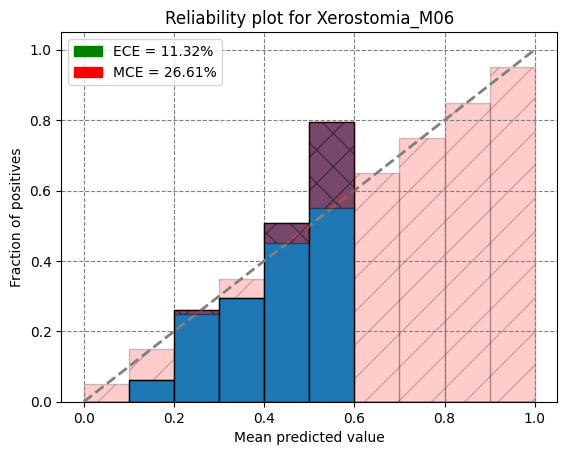

In [5]:
fig = plot_reliability(xero_preds, xero_labels, 'Reliability plot for Xerostomia_M06', n_bins=10)

In [4]:
from utils.calibration_plots import calc_bins, get_ECE_metrics



bins, _, bin_accs, bin_confs, bin_sizes = calc_bins(xero_preds, xero_labels, num_bins=10)

ECE, MCE = get_ECE_metrics(bins, _, bin_accs, bin_confs, bin_sizes)

ECE

NameError: name 'xero_preds' is not defined

In [4]:
def temperature_scale(logits, temperature):
    """
    Perform temperature scaling on logits
    """
    # Expand temperature to match the size of logits
    temperature = temperature.expand(logits.size(0))
    return logits / temperature


def set_temperature(logits, labels):
        logits = logits.float()
        labels = labels.float()

        temperature = nn.Parameter(torch.ones(1) * 1.5)
        """
        Tune the tempearature of the model (using the validation set).
        We're going to set it to optimize NLL.
        valid_loader (DataLoader): validation set loader
        """
        #self.cuda()
        nll_criterion = nn.BCEWithLogitsLoss().cuda()
        ece_criterion = ECE_Criterion().cuda()

        # Calculate NLL and ECE before temperature scaling
        before_temperature_nll = nll_criterion(logits, labels).item()
        before_temperature_ece = ece_criterion(logits, labels).item()
        print('Before temperature - NLL: %.3f, ECE: %.3f' % (before_temperature_nll, before_temperature_ece))

        # Next: optimize the temperature w.r.t. NLL
        optimizer = optim.LBFGS([temperature], lr=0.01, max_iter=50)

        #print(logits.shape)

        def eval():
            optimizer.zero_grad()
            loss = nll_criterion(temperature_scale(logits, temperature), labels)
            loss.backward()
            return loss
        optimizer.step(eval)

        temperature = torch.tensor(0.6)

        # Calculate NLL and ECE after temperature scaling
        temp_scaled_logits = temperature_scale(logits, temperature)

        #print(temp_scaled_logits == logits)
        after_temperature_nll = nll_criterion(temp_scaled_logits, labels).item()
        after_temperature_ece = ece_criterion(temp_scaled_logits.detach(), labels.detach()).item()
        print('Optimal temperature: %.3f' % temperature.item())
        print('After temperature - NLL: %.3f, ECE: %.3f' % (after_temperature_nll, after_temperature_ece))

        return temperature, temp_scaled_logits.detach()

temperature, temp_scaled_logits = set_temperature(xero_preds_logits, xero_labels)


temp_scaled_preds = torch.sigmoid(temp_scaled_logits)


fig1 = plot_reliability(xero_preds, xero_labels, 'Old Xerostomia_M06', n_bins=10)

fig2 = plot_reliability(temp_scaled_preds, xero_labels, 'Temp Scaled Xerostomia_M06', n_bins=10)

NameError: name 'xero_preds_logits' is not defined

[[1.9377693]] [0.63416541]


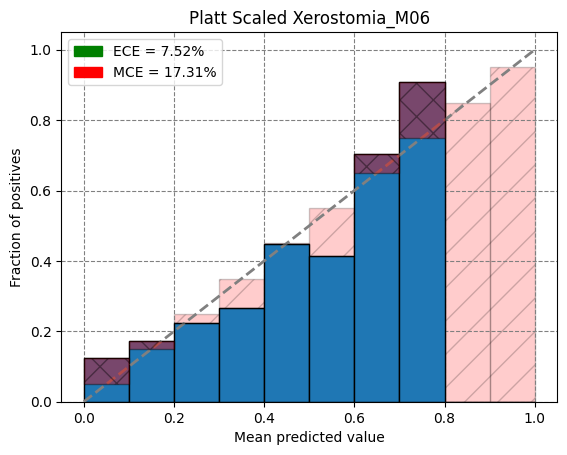

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression()

logreg_model.fit(xero_preds_logits.reshape(-1, 1), xero_labels)

logreg_preds = logreg_model.predict_proba(xero_preds_logits.reshape(-1, 1))[:, 1]


print(logreg_model.coef_, logreg_model.intercept_)

fig3 = plot_reliability(logreg_preds, xero_labels, 'Platt Scaled Xerostomia_M06', n_bins=10)

In [5]:
def get_and_filter_preds(df, endpoint):
    preds = df[endpoint + '_pred']
    labels = df[endpoint + '_true']

    mask = labels.isin([0, 1])

    preds = preds[mask]
    labels = labels[mask]

    preds = torch.tensor(preds.values)
    labels = torch.tensor(labels.values)

    preds_logits = torch.log(preds / (1 - preds))

    return preds_logits, preds, labels

In [9]:
%load_ext autoreload

exp_dir = r"experiments/TransRP_ResNet18_m2 more linear layers"
model_name = 'TransRP_ResNet18_m2'

endpoints = ['Aspiration_M06', 'Dysphagia_M06', 'Sticky_M06', 'Taste_M06', 'Xerostomia_M06']

folders = os.listdir(exp_dir)

from temperature_scaling import TemperatureScaler, PlattScaler, IsotonicRegressionScaler, BetaCalibration
prediction_scaling_methods = {"temperature scaling" : TemperatureScaler() , "platt scaling" : PlattScaler(), "isotonic regression":IsotonicRegressionScaler(), "beta calibration":BetaCalibration()}

original_results = {}
method_results = {}

for scaling_method, model in prediction_scaling_methods.items():

    ens_preds_dict = {endpoint: None for endpoint in endpoints}
    scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
    true_labels_dict = {endpoint: None for endpoint in endpoints}

    for folder in folders:
        if "_2_" in folder:
            continue
        print(folder)
        #print(folder)
        #print(folder)
        df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
        df_preds = pd.read_csv(df_preds_dir, delimiter=';')
        df_val = df_preds[df_preds['Mode'] == 'val']
        df_test = df_preds[df_preds['Mode'] == 'test']

        for endpoint in endpoints:
            # first find the scaling by using the validation set
            val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

            
            model.fit(val_logits, val_labels)

            test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)

            test_logreg_preds = model.predict_proba(test_logits)
            #test_logreg_preds = torch.tensor(test_logreg_preds)
            #logreg_preds = torch.sigmoid(torch.tensor(logreg_logits))

            if ens_preds_dict[endpoint] is None:
                ens_preds_dict[endpoint] = test_preds/5
                scaled_ens_preds_dict[endpoint] = test_logreg_preds/5
                true_labels_dict[endpoint] = test_labels
            else:
                ens_preds_dict[endpoint] += test_preds/5
                scaled_ens_preds_dict[endpoint] += test_logreg_preds/5

   
    method_results[scaling_method] = scaled_ens_preds_dict
            
            


method_results["original"] = ens_preds_dict
# true_labels_dict

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
20240629_144108_1_101_53_TransRP_ResNet18_m2_params_121917697_auc_tr_0.731_val_0.731_test_0.719
20240629_144108_3_101_46_TransRP_ResNet18_m2_params_121917697_auc_tr_0.743_val_0.672_test_0.721
20240629_144108_4_101_76_TransRP_ResNet18_m2_params_121917697_auc_tr_0.746_val_0.71_test_0.725
5_101_72_TransRP_ResNet18_m2_params_121917697_auc_tr_0.74_val_0.738_test_0.722_avg_tr_0.707_val_0.677_test_0.682_ens_0.725
20240629_144108_1_101_53_TransRP_ResNet18_m2_params_121917697_auc_tr_0.731_val_0.731_test_0.719
20240629_144108_3_101_46_TransRP_ResNet18_m2_params_121917697_auc_tr_0.743_val_0.672_test_0.721
20240629_144108_4_101_76_TransRP_ResNet18_m2_params_121917697_auc_tr_0.746_val_0.71_test_0.725
5_101_72_TransRP_ResNet18_m2_params_121917697_auc_tr_0.74_val_0.738_test_0.722_avg_tr_0.707_val_0.677_test_0.682_ens_0.725
20240629_144108_1_101_53_TransRP_ResNet18_m2_params_121917697_auc_tr_0.731_val_0.731_test_0.

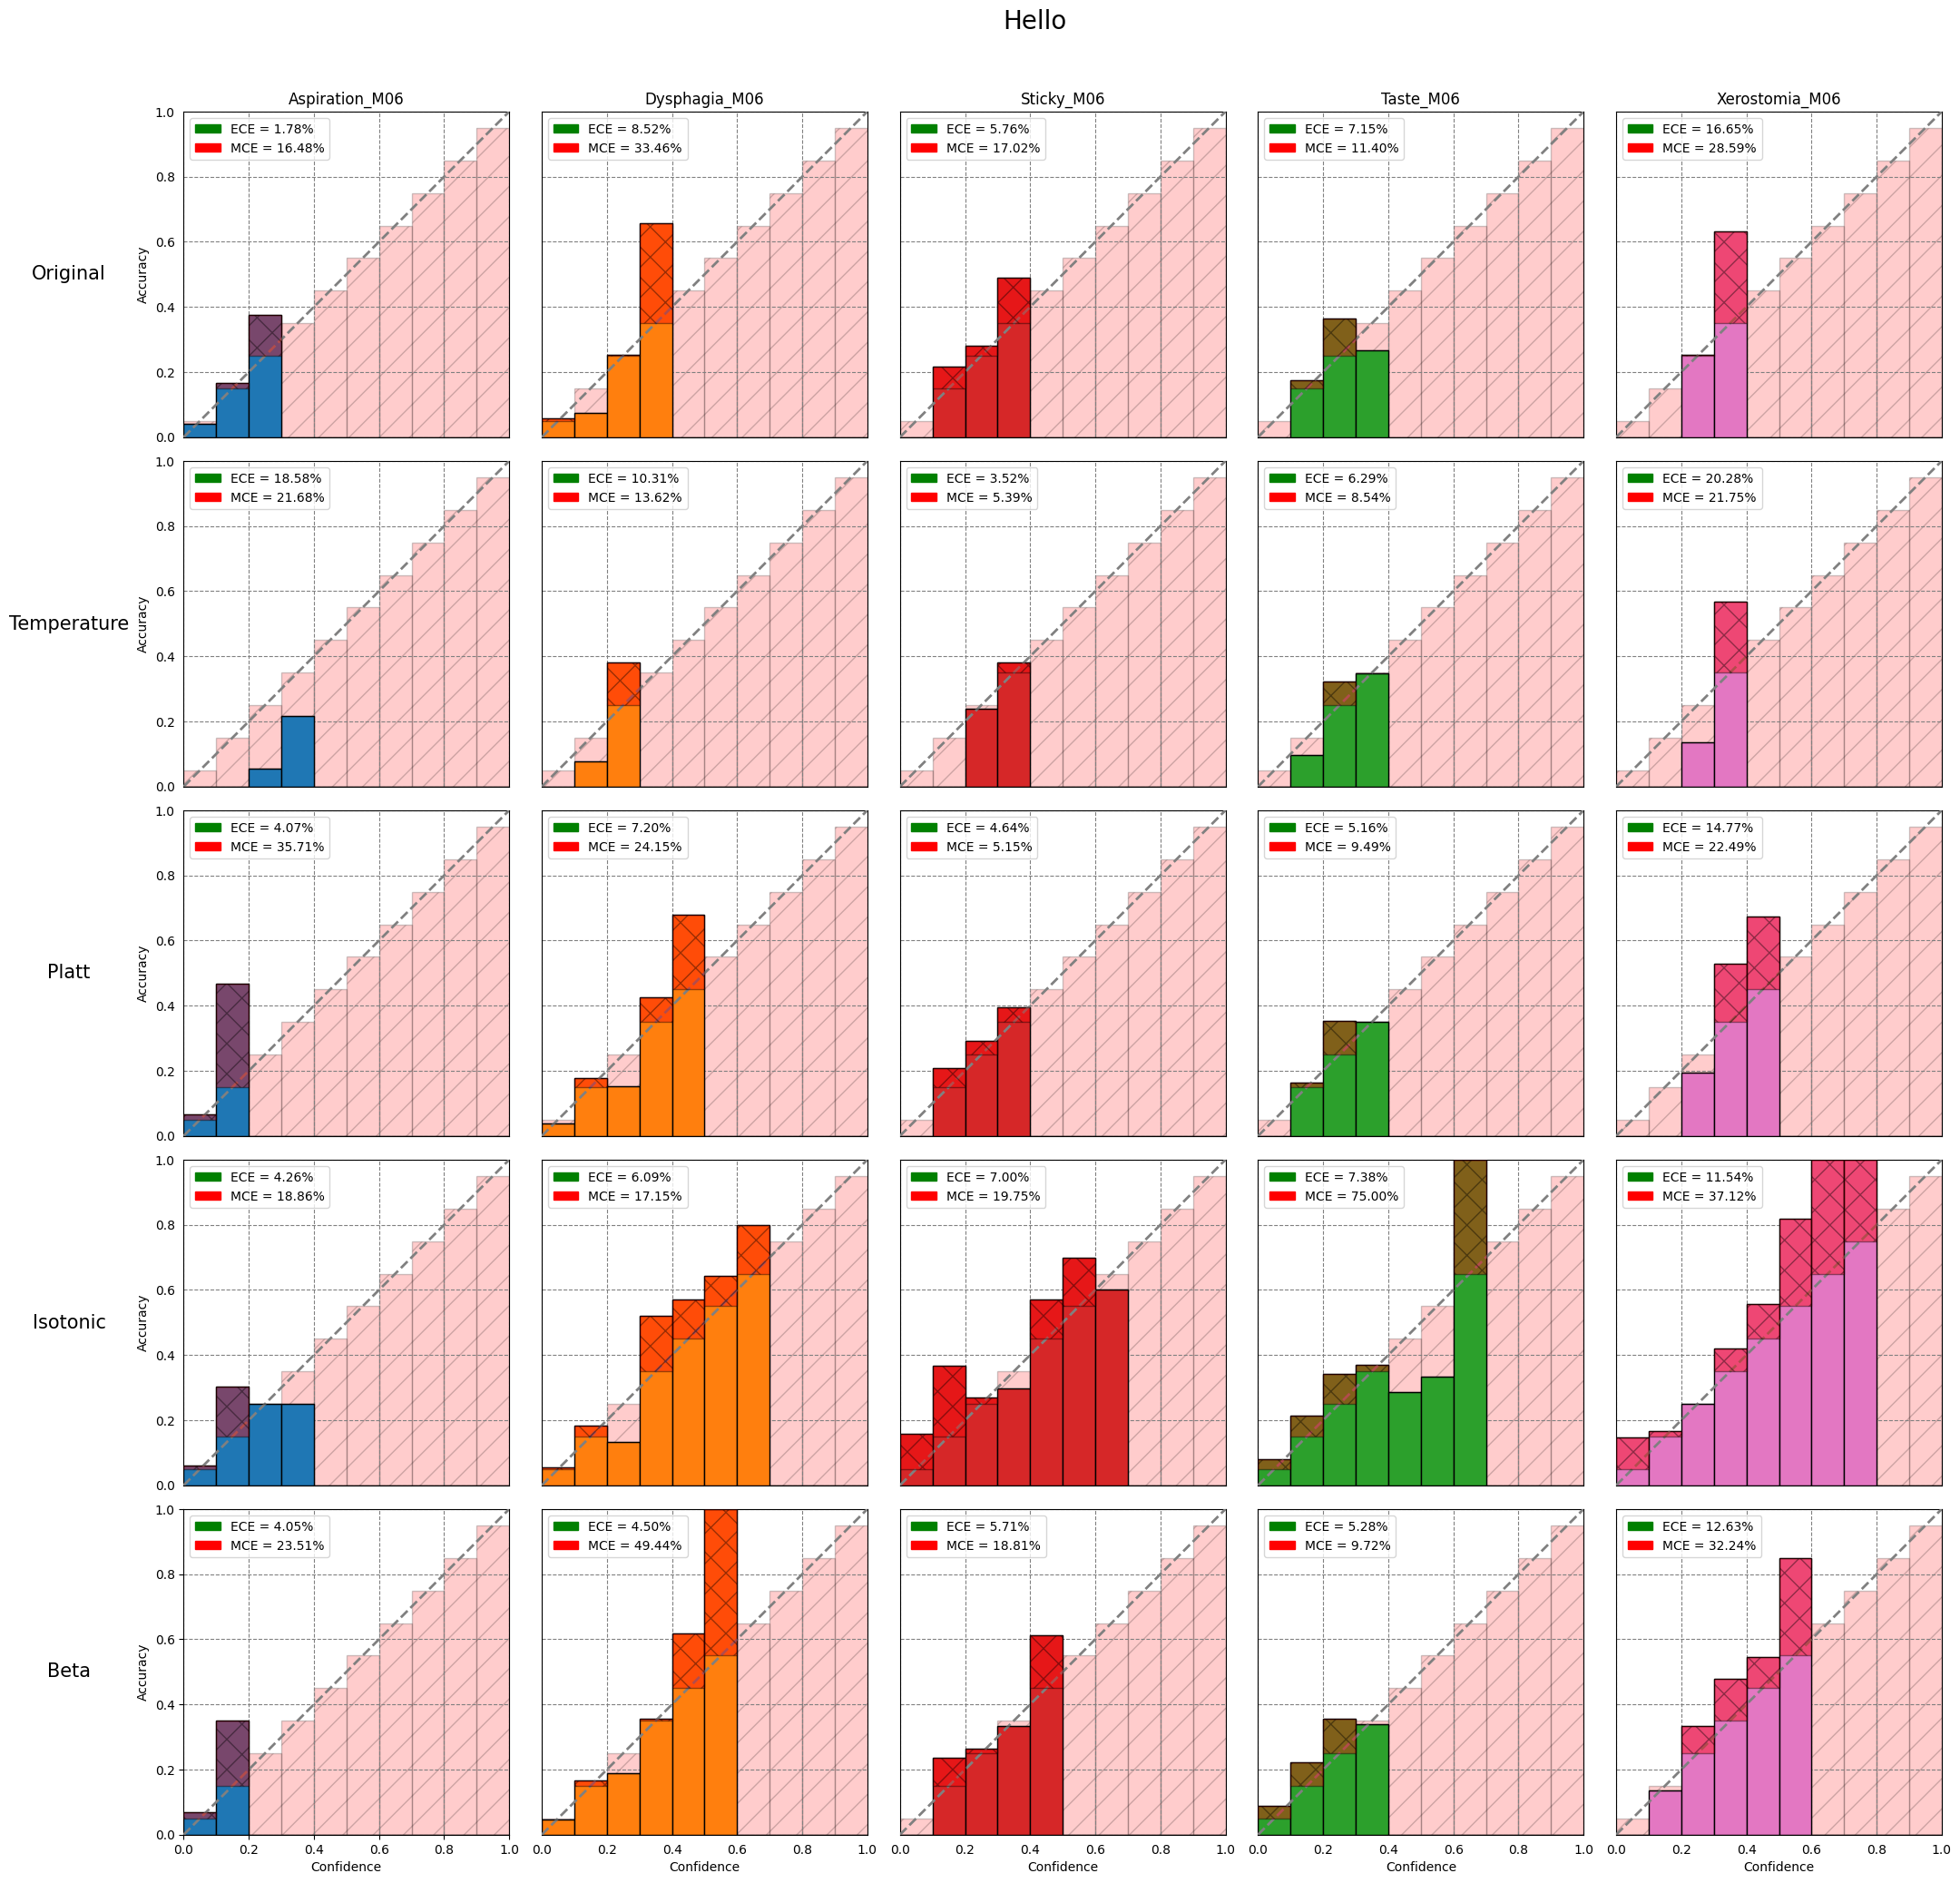

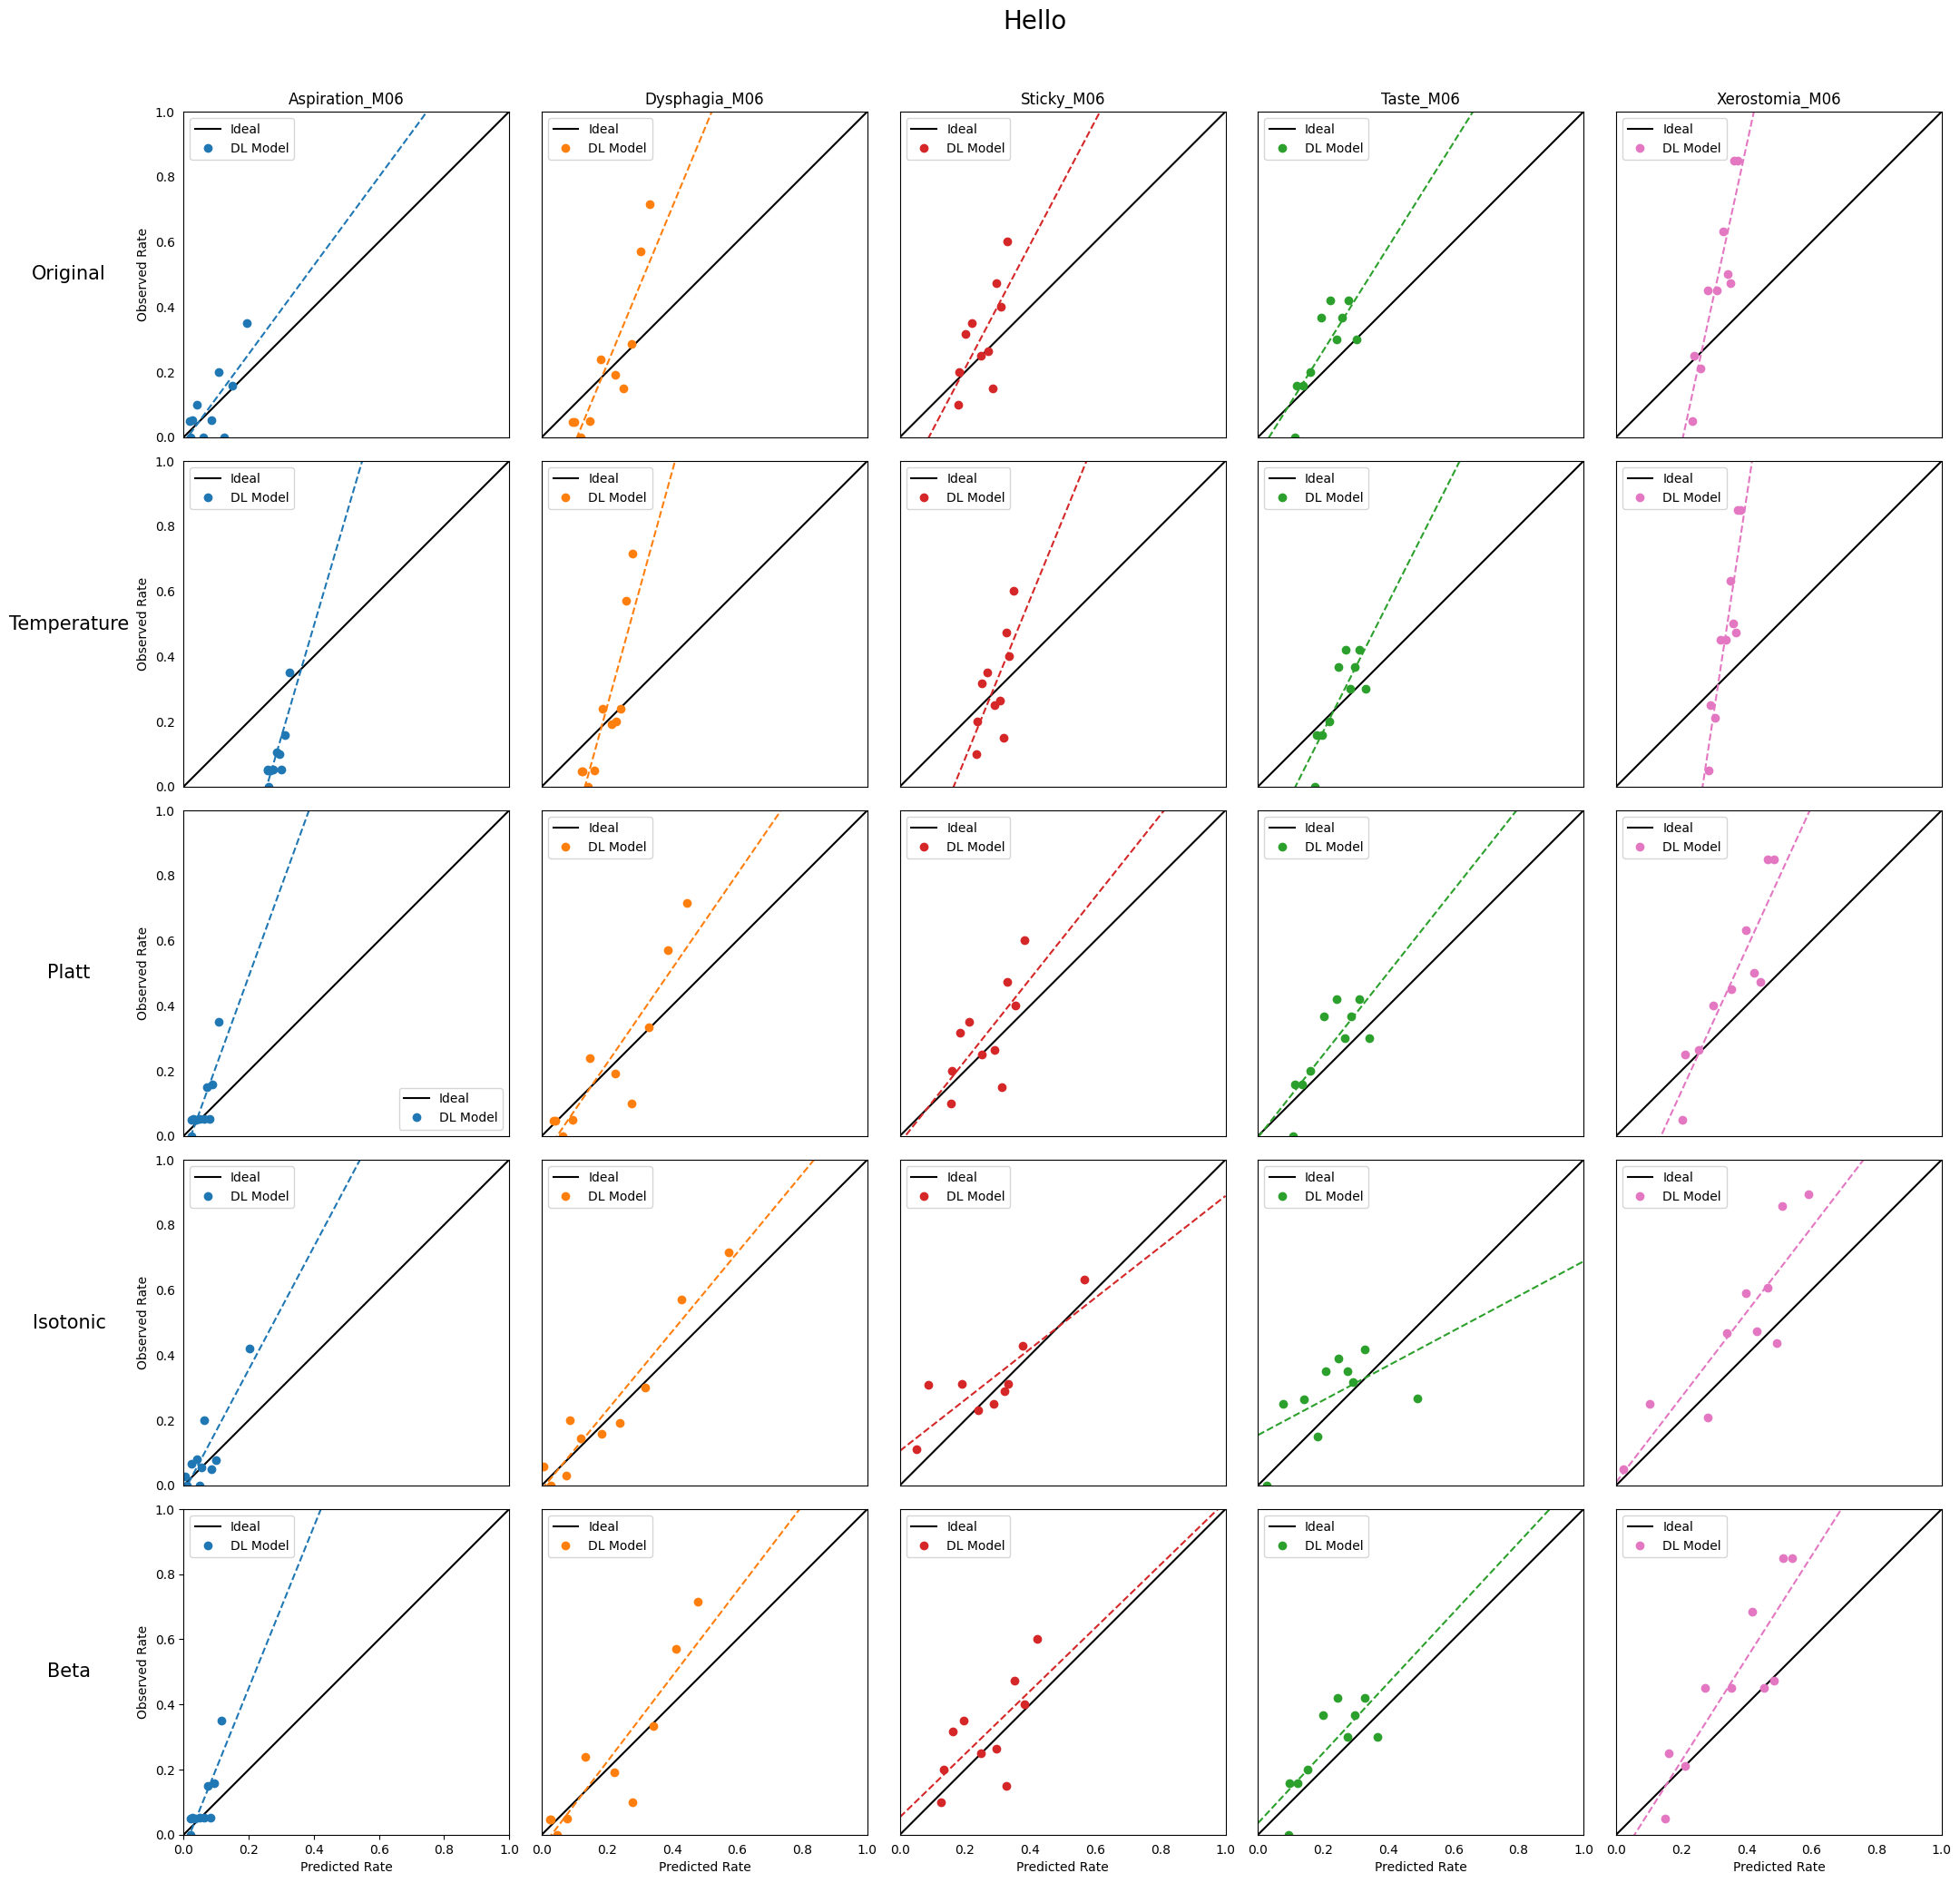

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import config

def adaptive_make_calibration_plots(row_dicts, column_names, title=None, mode='calibration', filedir=None):
    """
    Make calibration plots for multiple models. This code is flexible in how many rows and columns the diagram can have

    """

    ECE_dicts, MCE_dicts = [], []
    colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']


    # set the dimensions of the plot
    row_count = len(row_dicts)
    column_count = len(column_names)

    plot_width, plot_height = 5, 5

    fig_width = plot_width * column_count 
    fig_height = plot_height * row_count

    if mode == "calibration":
        #title = "Calibration Plot: {}".format(set_name)
        x_axis_label = "Predicted Rate"
        y_axis_label = "Observed Rate"
        
    elif mode == "reliability":
        #title = "Reliability Plot: {}".format(set_name)
        x_axis_label = "Confidence"
        y_axis_label = "Accuracy"
    else:
        raise ValueError("Calibration plotting mode must be either `calibration` or `reliability`")



    # Create a figure and axis
    # Create a gridspec to add a colorbar axis
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(
        row_count,
        column_count,
        width_ratios=[1] * column_count,
        hspace=0,
        wspace=0.1,
        figure=fig,
    )

    # Create title
    if title is not None:
        fig.suptitle(title, fontsize=20, y=0.92) # place the title at the top of the figure

    # Create subplots
    axs = [
        [plt.subplot(gs[i, j]) for j in range(column_count)] for i in range(row_count)
    ]

    for i, row_pred_dict in enumerate(row_dicts):
        #row_name = row_pred_dict['name']
        row_preds = row_pred_dict['preds']
        row_labels = row_pred_dict['labels']

        
        if mode == "calibration":
            make_row_calibration_plots(axs[i], row_preds, row_labels, column_names, 10, colours, DL_model=True)
        else:
            ECE_dict, MCE_dict = make_row_reliability_plots(axs[i], row_preds, row_labels, column_names, 10, colours, DL_model=True)
            ECE_dicts.append(ECE_dict)
            MCE_dicts.append(MCE_dict)


    for i in range(row_count):
        for j in range(column_count):
            axs[i][j].set_aspect("equal")
            if i != row_count - 1:
                axs[i][j].set_xticklabels([])
                axs[i][j].set_frame_on(True)
                axs[i][j].tick_params(tick1On=False)
                if i == 0:
                    axs[i][j].set_title(column_names[j])   # annotate column subtitle
            else:
                
                axs[i][j].set_xlabel(x_axis_label)
            
            if j != 0:
                axs[i][j].set_yticklabels([])
                axs[i][j].set_frame_on(True)
                axs[i][j].tick_params(tick1On=False)
            else:   
                axs[i][j].set_ylabel(y_axis_label)
                axs[i][j].annotate(         # annotate row subtitle
                    row_dicts[i]["name"],
                    xy=(0, 0.5),
                    xytext=(-axs[i][j].yaxis.labelpad - 50, 0),
                    xycoords=axs[i][j].yaxis.label,
                    textcoords="offset points",
                    size=15,
                    ha="center",
                    va="center",
                )

            axs[i][j].set_xlim(0, 1)
            axs[i][j].set_ylim(0, 1)

    if filedir is not None:
        plt.savefig(filedir)

    #plt.close()

    if mode == 'reliability':
        return ECE_dicts, MCE_dicts

    


    # for idx, (ax, endpoint) in enumerate(zip(axs[0], config.endpoint_list)):
    #     ax.set_title(endpoint, fontdict={'fontsize': 13})






def make_row_calibration_plots(row_ax, preds, labels, column_names, n_bins, colours, DL_model=True):
    #print(preds)
    for i, col_name in enumerate(column_names):
    #    print(i)
    #for ax, i in enumerate(row_ax):
        calibration_subplot(row_ax[i], preds[col_name], labels[col_name], colours[i], DL_model, n_bins)


def make_row_reliability_plots(row_ax, preds, labels, column_names, n_bins, colours, DL_model=True):
    ECE_dict = {}
    MCE_dict = {}
    for i, col_name in enumerate(column_names):
        ECE, MCE = reliability_subplot(row_ax[i], preds[col_name], labels[col_name], n_bins, colours[i], DL_model)
        ECE_dict[col_name] = ECE
        MCE_dict[col_name] = MCE

    return ECE_dict, MCE_dict
    

def reliability_subplot(ax, y_pred_all, y_true_all, n_bins, colour, DL_model = True):
    mask = [True if x in config.valid_endpoint_values else False for x in y_true_all]

    y_true = y_true_all[mask]
    y_pred = y_pred_all[mask]

    bins, _, bin_accs, bin_confs, bin_sizes = calc_bins(y_pred, y_true, num_bins=n_bins)

    ECE, MCE = get_ECE_metrics(bins, _, bin_accs, bin_confs, bin_sizes)

    bin_centers = bins - 0.05

    # Error bars (light red bars)
    ax.bar(bin_centers, bin_centers,  width=0.1, alpha=0.2, edgecolor='black', color='r', hatch='/', zorder=1)

    # Draw (blue) bars and identity line
    ax.bar(bin_centers, bin_accs, width=0.1, alpha=1, edgecolor='black', color=colour, zorder=2)
    ax.plot([0,1],[0,1], '--', color='gray', linewidth=2, zorder=3)

    # ECE and MCE legend
    ECE_patch = mpatches.Patch(color='green', label='ECE = {:.2f}%'.format(ECE*100))
    MCE_patch = mpatches.Patch(color='red', label='MCE = {:.2f}%'.format(MCE*100))
    ax.legend(handles=[ECE_patch, MCE_patch])

    # Create grid
    ax.grid(True, color='gray', linestyle='dashed', zorder=0)

    # plot gaps
    gaps = (bin_accs - bin_centers) 
    gaps = np.clip(gaps, 0, 1)

    #gaps = gaps if gaps > 0 else 0
    ax.bar(bin_centers, gaps, bottom = np.minimum(bin_accs, (bins-0.05)),
                width=0.1, alpha=0.4, edgecolor='black', color='r', hatch='\\/', zorder=3)
    
    ECE = round(ECE, config.nr_of_decimals)
    MCE = round(MCE, config.nr_of_decimals)

    return ECE, MCE


def calibration_subplot(ax, y_pred_all, y_true_all, colour, DL_model = True, n_bins=10):
    
    x = [0,1]
    y = [0,1]

    mask = [True if x in config.valid_endpoint_values else False for x in y_true_all]

    y_true = y_true_all[mask]
    y_pred = y_pred_all[mask]

    fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_pred, pos_label=1, n_bins=n_bins, strategy="quantile")

    coef = np.polyfit(mean_predicted_value, fraction_of_positives, 1)
    linear_fit = np.poly1d(coef)

    # plot the points (scatter)
    shape = 'o' if DL_model else 's'
    label = "DL Model" if DL_model else "CITOR"

    ax.plot([0, 1], [0, 1], "black", label="Ideal") # plot the ideal line

    ax.plot(mean_predicted_value, fraction_of_positives, shape, label=label, color=colour)
    # plot the best fit line
    ax.plot(x, linear_fit(y), '--',   color=colour)
    
    ax.legend()


def bin_predictions(y_prob, y_true, strategy, n_bins):
    if strategy == "quantile":  # Determine bin edges by distribution of data
        quantiles = np.linspace(0, 1, n_bins + 1)
        bins = np.percentile(y_prob, quantiles * 100)
    elif strategy == "uniform":
        bins = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        raise ValueError(
            "Invalid entry to 'strategy' input. Strategy "
            "must be either 'quantile' or 'uniform'."
        )

    binids = np.searchsorted(bins[1:-1], y_prob)

    bin_sums = np.bincount(binids, weights=y_prob, minlength=len(bins))
    bin_true = np.bincount(binids, weights=y_true, minlength=len(bins))
    bin_total = np.bincount(binids, minlength=len(bins))

    nonzero = bin_total != 0
    prob_true = bin_true[nonzero] / bin_total[nonzero]
    prob_pred = bin_sums[nonzero] / bin_total[nonzero]

    prob_true_std = np.sqrt(prob_true * (1 - prob_true) / bin_total[nonzero])
    prob_pred_std = np.sqrt(prob_pred * (1 - prob_pred) / bin_total[nonzero])

    return prob_true, prob_pred, prob_true_std, prob_pred_std



big_results_dict = [
    {
        "name": "Original",
        "preds": method_results["original"], 
        "labels": true_labels_dict
    }, {
        "name": "Temperature", 
        "preds": method_results["temperature scaling"], 
        "labels": true_labels_dict
    }, {
        "name": "Platt", 
        "preds": method_results["platt scaling"], 
        "labels": true_labels_dict
    },
    {"name": "Isotonic", "preds": method_results["isotonic regression"], "labels": true_labels_dict},
    {"name": "Beta", "preds": method_results["beta calibration"], "labels": true_labels_dict}
]


fig = adaptive_make_calibration_plots(row_dicts=big_results_dict, column_names=endpoints, title="Hello", mode='reliability')
plt.show()
plt.close()
fig = adaptive_make_calibration_plots(row_dicts=big_results_dict, column_names=endpoints, title="Hello", mode='calibration')
plt.show()
plt.close()

In [25]:

def bin_predictions(y_prob, y_true, strategy, n_bins):
    if strategy == "quantile":  # Determine bin edges by distribution of data
        quantiles = np.linspace(0, 1, n_bins + 1)
        bins = np.percentile(y_prob, quantiles * 100)
    elif strategy == "uniform":
        bins = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        raise ValueError(
            "Invalid entry to 'strategy' input. Strategy "
            "must be either 'quantile' or 'uniform'."
        )

    binids = np.searchsorted(bins[1:-1], y_prob)

    #print(binids)
    #print(y_prob.shape, y_true.shape, len(bins))

    mean_bin_probs = []
    mean_bin_trues = []
    std_bin_probs = []
    std_bin_trues = []

    for bin in range(n_bins):
        bin_probs = np.array(y_prob[binids == bin])
        bin_trues = np.array(y_true[binids == bin])

        print(len(bin_probs), len(bin_trues))



        # bin_sums2.append(bin_probs.sum().item())
        # bin_true2.append(bin_trues.sum().item())
        # bin_total2.append(len(bin_trues))

        #prob_true = np.array(bin_true2) / np.array(bin_total2)
        prob_true = bin_trues.mean()
        prob_pred = bin_probs.mean()

        mean_bin_probs.append(prob_pred)
        mean_bin_trues.append(prob_true)

        
        pred_std = bin_probs.std(ddof=1)
        true_std = bin_trues.std(ddof=1)

        std_bin_probs.append(pred_std)
        std_bin_trues.append(true_std)

        # true_std = np.sqrt(prob_true * (1 - prob_true) / len(bin_trues))
        # pred_std = np.sqrt(prob_pred * (1 - prob_pred) / len(bin_trues))

        # print("1", true_std, pred_std)

        #print(bin_trues)

    print(bin_probs)
    print(bin_trues)

    mean_bin_probs = np.array(mean_bin_probs)
    mean_bin_trues = np.array(mean_bin_trues)
    std_bin_probs = np.array(std_bin_probs)
    std_bin_trues = np.array(std_bin_trues)


    # print(bin_sums2, bin_true2, bin_total2)

    # print(bin_sums[nonzero])
    # print(bin_true[nonzero])
    # print(bin_total[nonzero])

    return mean_bin_probs, mean_bin_trues, std_bin_probs, std_bin_trues


y_true = true_labels_dict['Dysphagia_M06']
y_prob = method_results["original"]['Dysphagia_M06']

mean_bin_probs, mean_bin_trues, std_bin_probs, std_bin_trues = bin_predictions(y_prob, y_true, "quantile", 10)
print(std_bin_probs, std_bin_trues)


21 21
21 21
21 21
20 20
21 21
21 21
20 20
21 21
21 21
21 21
[0.47525904 0.52950582 0.51181493 0.51487589 0.51961742 0.50443465
 0.49544939 0.51572795 0.51512259 0.53848666 0.49797445 0.51791946
 0.52413962 0.51630576 0.51710099 0.49061474 0.53662536 0.52948664
 0.54200062 0.50333085 0.4778741 ]
[1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1]
[0.00507858 0.00492933 0.00560532 0.01118623 0.01221599 0.01489483
 0.0160777  0.01462298 0.02195476 0.01828886] [0.21821789 0.21821789 0.21821789 0.2236068  0.35856858 0.43643578
 0.41039134 0.46291005 0.48304589 0.3007926 ]


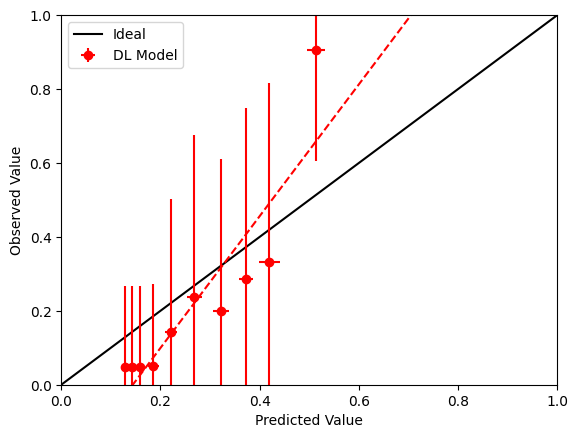

In [26]:
x = [0,1]
y = [0,1]
coef = np.polyfit(mean_bin_probs, mean_bin_trues, 1)
linear_fit = np.poly1d(coef)

# plot the points (scatter)
shape = 'o' 
label = "DL Model" 

plt.plot([0, 1], [0, 1], "black", label="Ideal") # plot the ideal line

plt.errorbar(mean_bin_probs, mean_bin_trues, label=label, color='red', fmt='o', yerr=std_bin_trues, xerr=std_bin_probs)
# plot the best fit line
plt.plot(x, linear_fit(y), '--',   color='red')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Predicted Value')
plt.ylabel('Observed Value')


plt.legend()

In [47]:
array = np.array([0.5225, 0.5298, 0.5147, 0.5195, 0.5096, 0.5107, 0.5220, 0.5190, 0.5118,
        0.5217, 0.5204, 0.5298, 0.5096, 0.5122, 0.5228, 0.5237, 0.5244, 0.5140,
        0.5126, 0.5221])

array = np.array([1,0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
 0, 0, 1, 1, 1])

print(array.mean(), array.std(ddof=1))

0.6428571428571429 0.4849656045851726


[ 3.86348609  4.65711576  6.30439421  7.70086066  8.32318679  8.39727319
  9.341868    9.39297299 10.37297256 11.05413184]
[ 2.  6.  3.  8.  7.  8. 13. 13. 15. 18.]
[20 20 19 20 20 19 20 19 20 20]

In [20]:

pred_original = method_results["original"]['Xerostomia_M06']
labels_original = true_labels_dict['Xerostomia_M06']

pred_temp = method_results["temperature scaling"]['Xerostomia_M06']


In [21]:
method_results.keys()

dict_keys(['temperature scaling', 'platt scaling', 'isotonic regression', 'beta calibration', 'original'])

In [22]:
true_labels_dict["Xerostomia_M06"].unique()

tensor([0, 1])

In [11]:
from utils.metrics import compute_AUCs_for_multiple_endpoints
from sklearn.metrics import roc_auc_score

#compute_AUCs_for_multiple_endpoints(config, method_results["original"], true_labels_dict)

for endpoint in config.endpoint_list:
    print(endpoint)
    for key in method_results.keys():
        
    
        auc_value = roc_auc_score(true_labels_dict[endpoint].clone().detach().cpu().numpy(), method_results[key][endpoint].clone().detach().cpu().numpy())
        #auc_value_new = roc_auc_score(true_labels_dict[endpoint].clone().detach().cpu().numpy(), method_results["temperature scaling"][endpoint].clone().detach().cpu().numpy())
        print(f"  {auc_value:.4f}",  key )

#auc_value = roc_auc_score(true_labels_dict["Xerostomia_M06"].clone().detach().cpu().numpy(), method_results["original"]['Xerostomia_M06'].clone().detach().cpu().numpy())

Aspiration_M06
  0.7257 temperature scaling
  0.7356 platt scaling
  0.7438 isotonic regression
  0.7356 beta calibration
  0.7353 original
Dysphagia_M06
  0.8286 temperature scaling
  0.8286 platt scaling
  0.8253 isotonic regression
  0.8284 beta calibration
  0.8293 original
Sticky_M06
  0.6467 temperature scaling
  0.6472 platt scaling
  0.6367 isotonic regression
  0.6469 beta calibration
  0.6466 original
Taste_M06
  0.6494 temperature scaling
  0.6494 platt scaling
  0.6495 isotonic regression
  0.6498 beta calibration
  0.6495 original
Xerostomia_M06
  0.7672 temperature scaling
  0.7665 platt scaling
  0.7626 isotonic regression
  0.7666 beta calibration
  0.7673 original


20240622_180411_1_101_61_TransRP_ResNet18_m2_params_121328961_auc_tr_0.786_val_0.737_test_0.715
20240622_180411_2_101_54_TransRP_ResNet18_m2_params_121328961_auc_tr_0.776_val_0.744_test_0.732
20240622_180411_3_101_26_TransRP_ResNet18_m2_params_121328961_auc_tr_0.743_val_0.704_test_0.714
20240622_180411_4_101_17_TransRP_ResNet18_m2_params_121328961_auc_tr_0.711_val_0.695_test_0.699
20240622_180411_5_101_37_TransRP_ResNet18_m2_params_121328961_auc_tr_0.751_val_0.727_test_0.722_avg_tr_0.753_val_0.721_test_0.716_ens_0.732


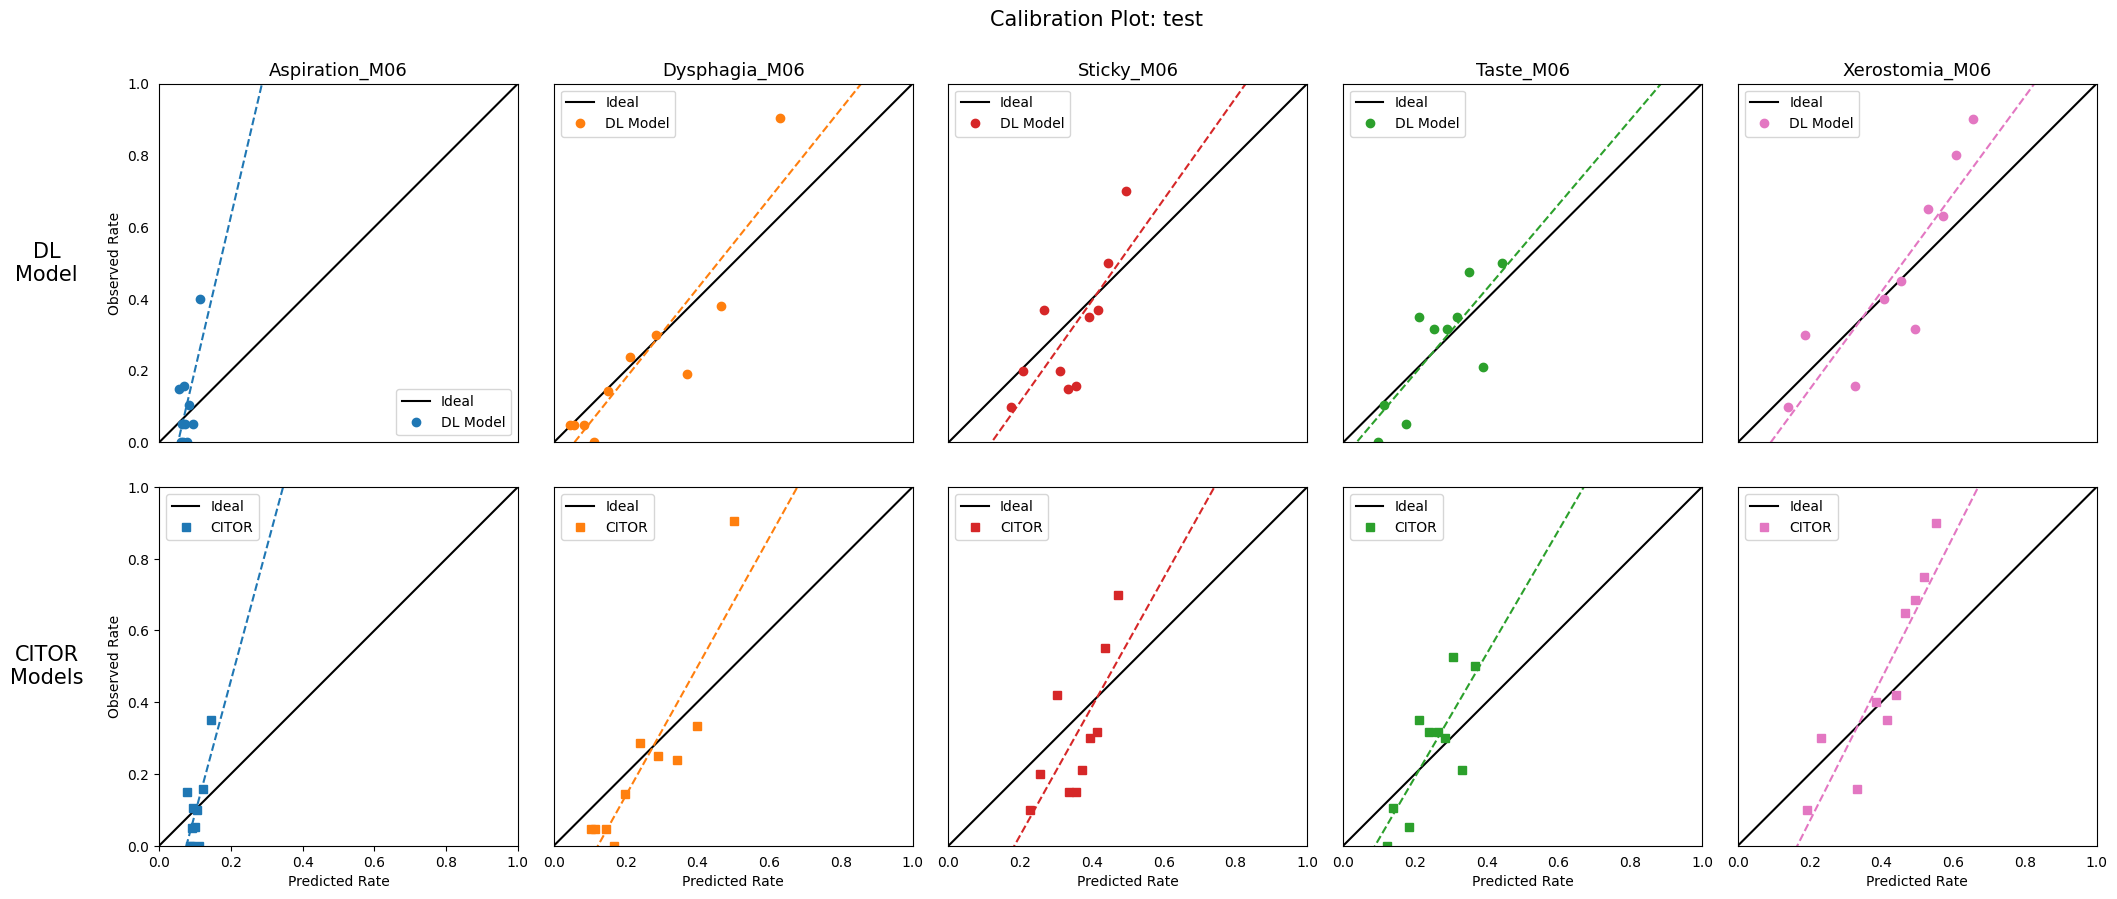

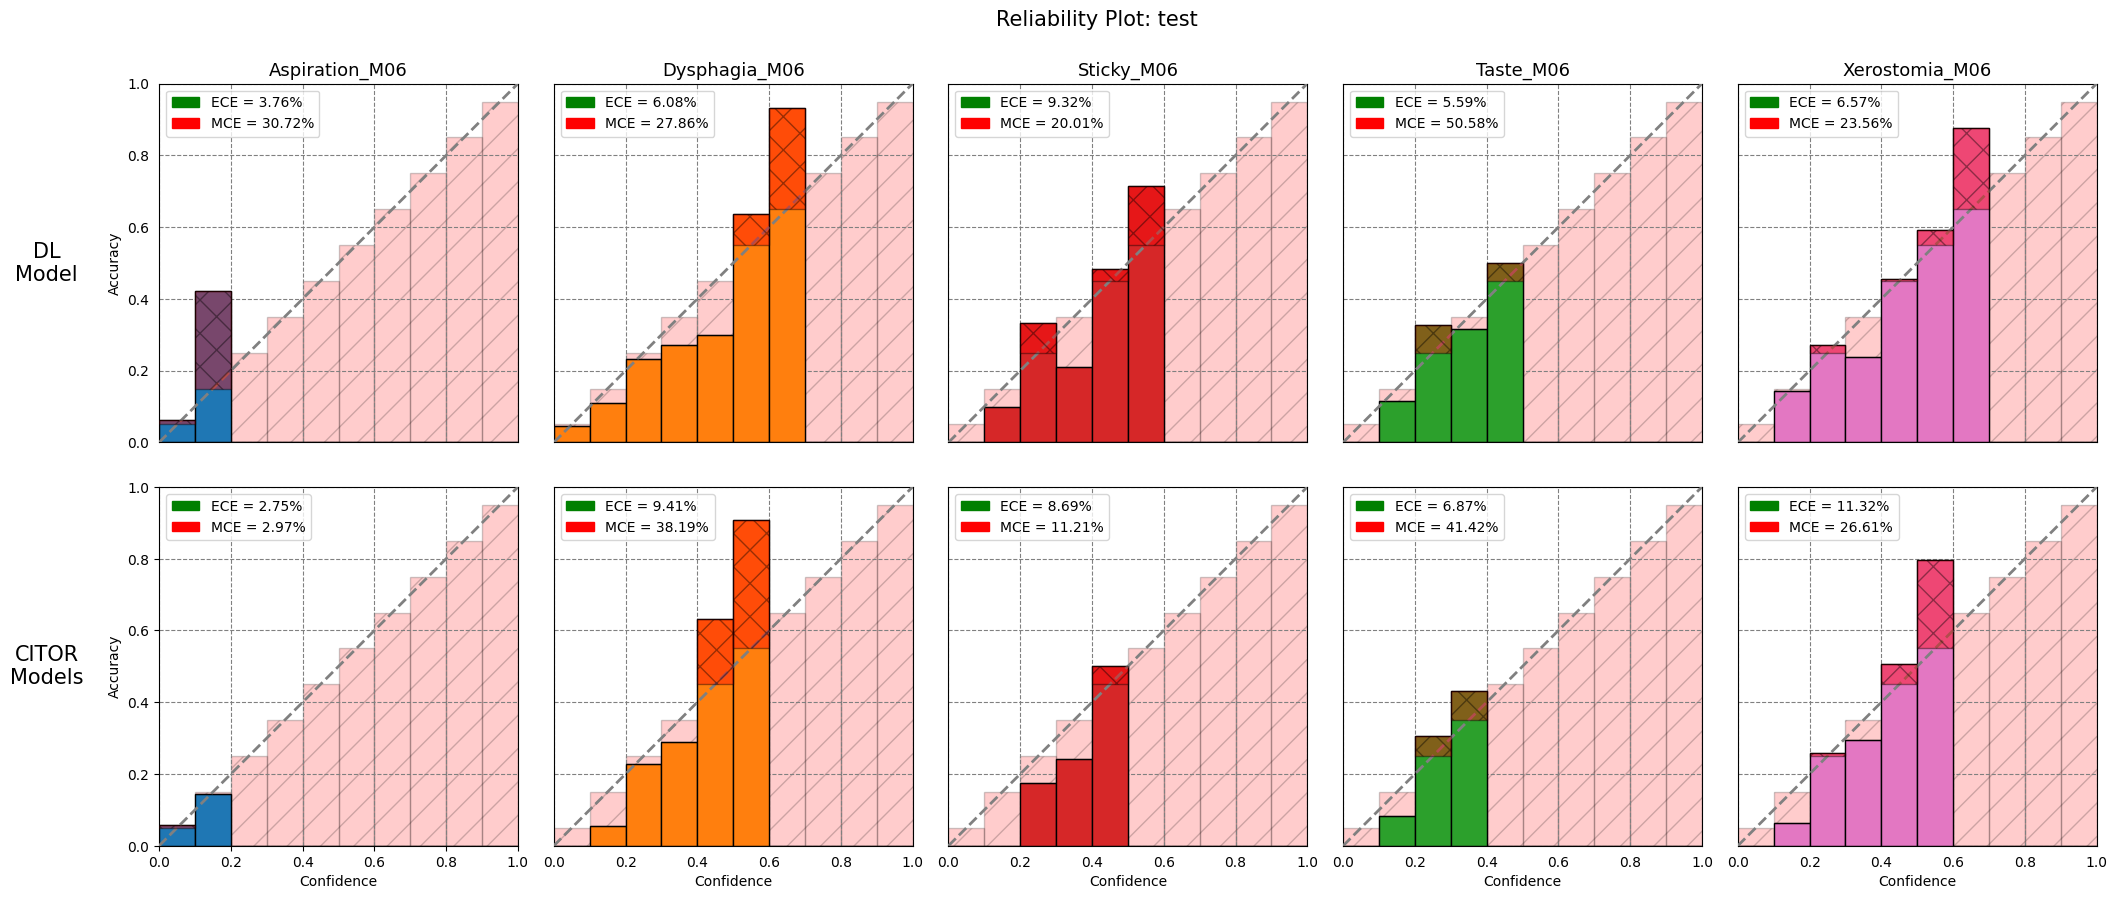

In [ ]:
exp_dir = r"experiments/TransRP_ResNet18_m2"
model_name = 'TransRP_ResNet18_m2'

endpoints = ['Aspiration_M06', 'Dysphagia_M06', 'Sticky_M06', 'Taste_M06', 'Xerostomia_M06']

folders = os.listdir(exp_dir)


logreg_model = LogisticRegression()


class PlattScaler():
    def __init__(self):
        self.lr = LogisticRegression()
    def fit(self, X, y):
        self.X = X
        self.y = y
        self.lr.fit(X.reshape(-1, 1), y)
    def predict_proba(self, X):
        return torch.tensor(self.lr.predict_proba(X.reshape(-1, 1))[:, 1])
    
logreg_model = PlattScaler()

ens_preds_dict = {endpoint: None for endpoint in endpoints}
scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
true_labels_dict = {endpoint: None for endpoint in endpoints}

for folder in folders:
    print(folder)
    df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
    df_preds = pd.read_csv(df_preds_dir, delimiter=';')
    df_val = df_preds[df_preds['Mode'] == 'val']
    df_test = df_preds[df_preds['Mode'] == 'test']

    for endpoint in endpoints:
        # first find the scaling by using the validation set
        val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

        
        logreg_model.fit(val_logits, val_labels)

        test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)

        test_logreg_preds = logreg_model.predict_proba(test_logits)
        #test_logreg_preds = torch.tensor(test_logreg_preds)
        #logreg_preds = torch.sigmoid(torch.tensor(logreg_logits))

        if ens_preds_dict[endpoint] is None:
            ens_preds_dict[endpoint] = test_preds/5
            scaled_ens_preds_dict[endpoint] = test_logreg_preds/5
            true_labels_dict[endpoint] = test_labels
        else:
            ens_preds_dict[endpoint] += test_preds/5
            scaled_ens_preds_dict[endpoint] += test_logreg_preds/5
        
        

        #fig3 = plot_reliability(preds, xero_labels, 'Xerostomia_M06', n_bins=10)
        #fig3 = plot_reliability(logreg_preds, xero_labels, 'Platt Scaled Xerostomia_M06', n_bins=10)

        
       
        #given_preds_logits = torch.log(given_preds / (1 - given_preds))

        #temperature, temp_scaled_logits = set_temperature(given_preds_logits, given_labels, print_info=False)

from utils.calibration_plots import make_calibration_plots_2
import config
fig = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='calibration')
plt.show()
fig2 = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='reliability')
plt.show()

20240622_180411_1_101_61_TransRP_ResNet18_m2_params_121328961_auc_tr_0.786_val_0.737_test_0.715
20240622_180411_2_101_54_TransRP_ResNet18_m2_params_121328961_auc_tr_0.776_val_0.744_test_0.732
20240622_180411_3_101_26_TransRP_ResNet18_m2_params_121328961_auc_tr_0.743_val_0.704_test_0.714
20240622_180411_4_101_17_TransRP_ResNet18_m2_params_121328961_auc_tr_0.711_val_0.695_test_0.699
20240622_180411_5_101_37_TransRP_ResNet18_m2_params_121328961_auc_tr_0.751_val_0.727_test_0.722_avg_tr_0.753_val_0.721_test_0.716_ens_0.732


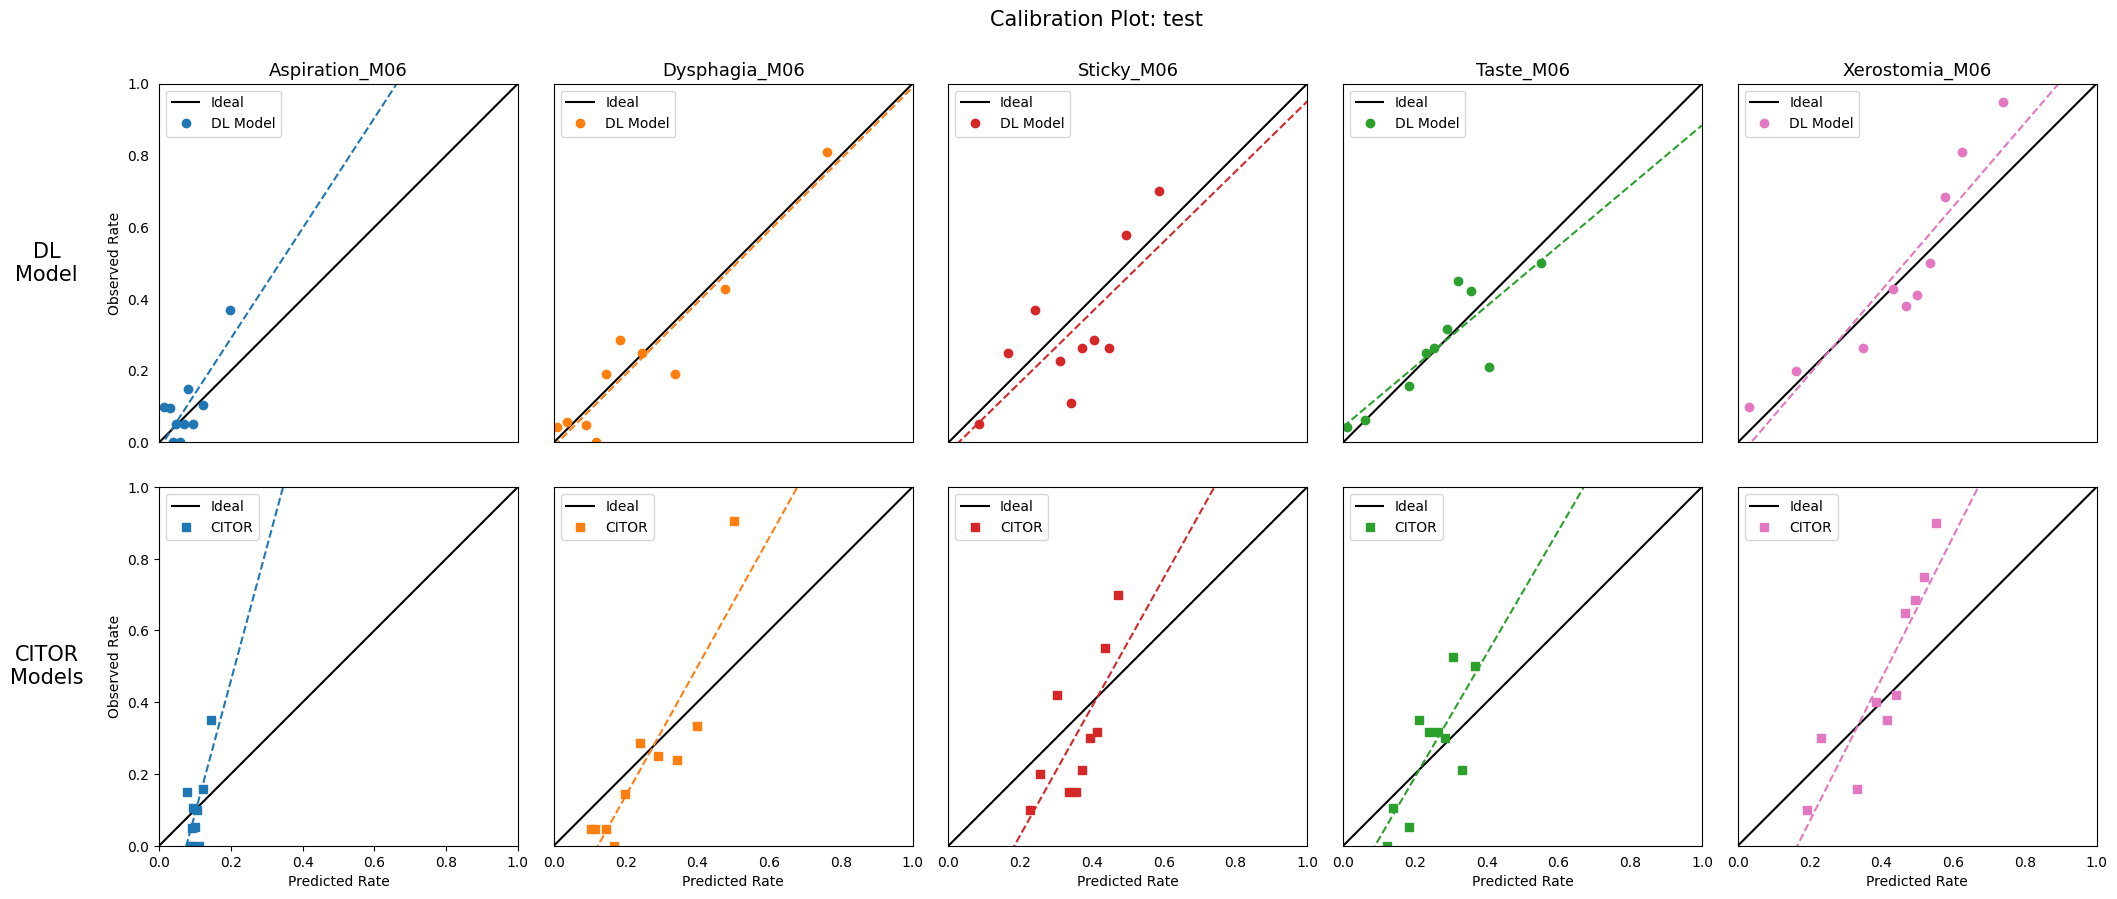

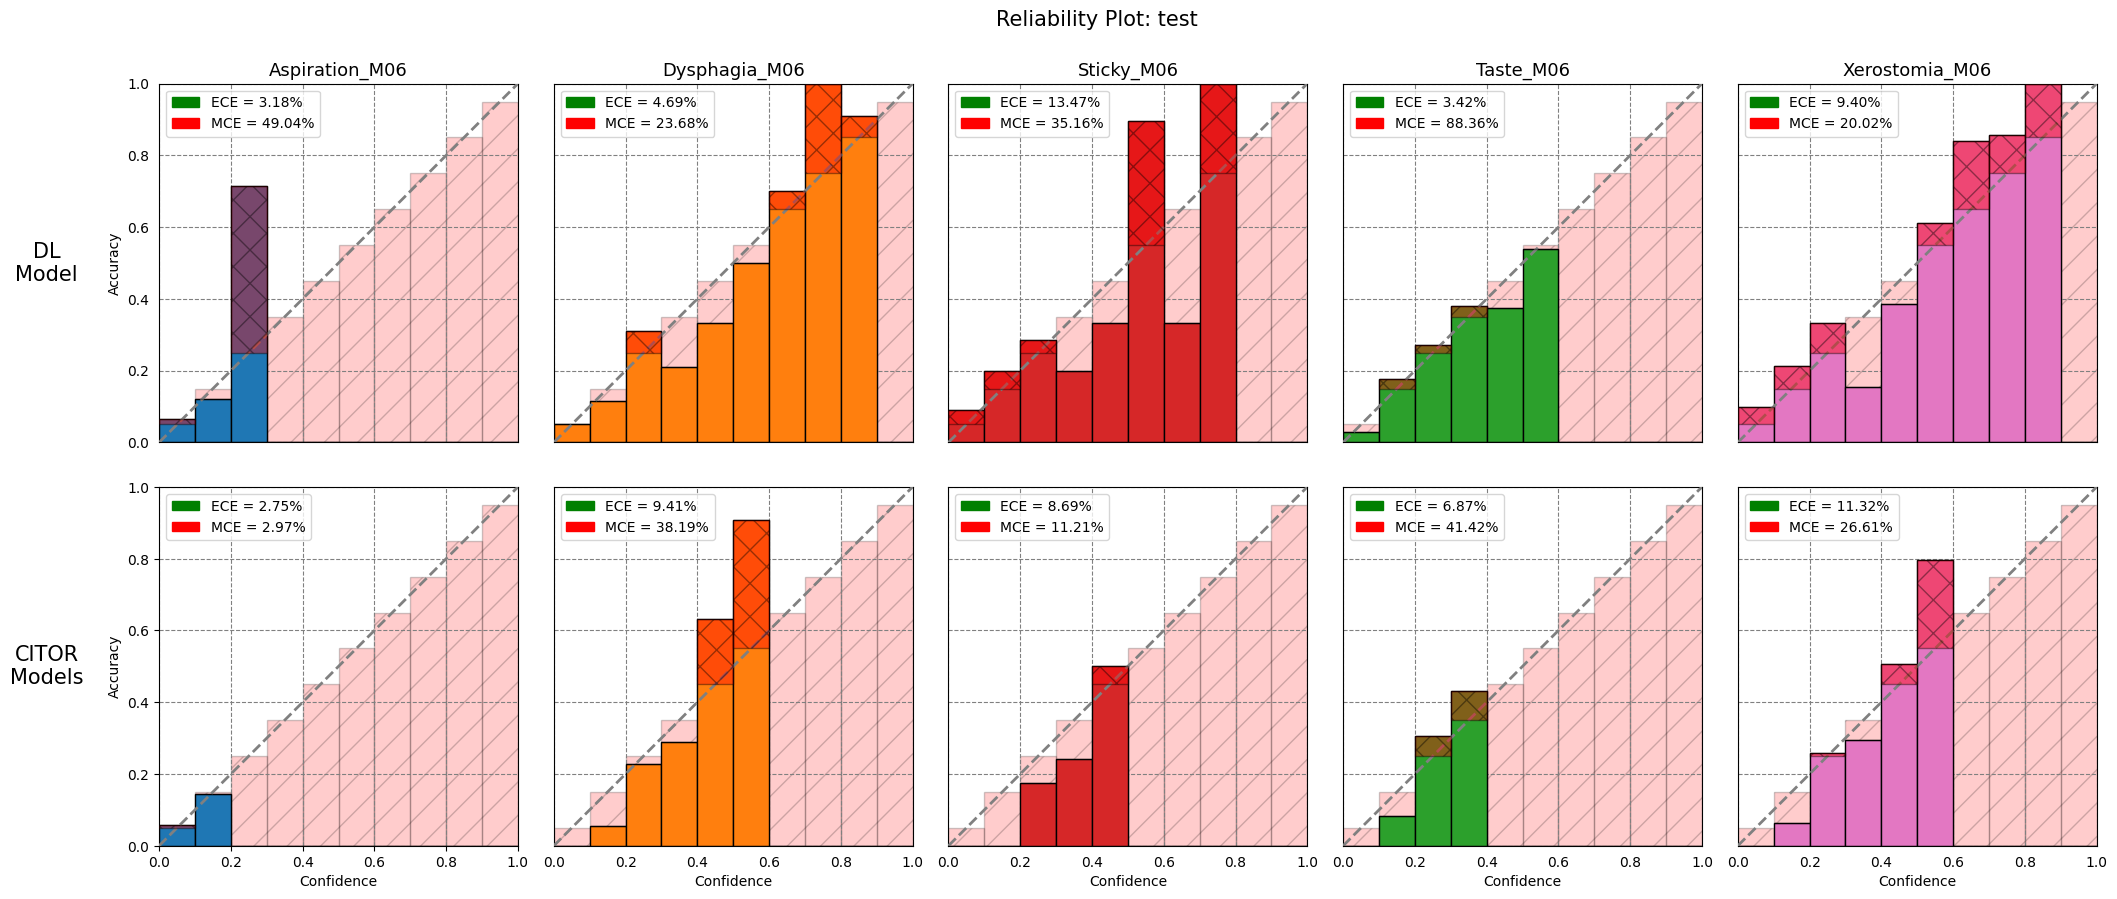

In [ ]:
from sklearn.isotonic import IsotonicRegression



#isotonic_model = IsotonicRegression(out_of_bounds='clip')

class IsotonicRegressionScaler():
    def __init__(self):
        self.ir = IsotonicRegression(out_of_bounds='clip') # must clip out of bounds, or else this will return NaNs
    def fit(self, X, y):
        self.X = X
        self.y = y
        self.ir.fit(X, y)
    def predict_proba(self, X):
        return self.ir.transform(X)

isotonic_model = IsotonicRegressionScaler()

ens_preds_dict = {endpoint: None for endpoint in endpoints}
scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
true_labels_dict = {endpoint: None for endpoint in endpoints}

for folder in folders:
    print(folder)
    df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
    df_preds = pd.read_csv(df_preds_dir, delimiter=';')
    df_val = df_preds[df_preds['Mode'] == 'val']
    df_test = df_preds[df_preds['Mode'] == 'test']

    for endpoint in endpoints:
        # first find the scaling by using the validation set
        val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

        
        isotonic_model.fit(val_logits, val_labels)

        test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)

        test_logreg_preds = isotonic_model.predict_proba(test_logits)
        test_logreg_preds = torch.tensor(test_logreg_preds)
        #logreg_preds = torch.sigmoid(torch.tensor(logreg_logits))

        if ens_preds_dict[endpoint] is None:
            ens_preds_dict[endpoint] = test_preds/5
            scaled_ens_preds_dict[endpoint] = test_logreg_preds/5
            true_labels_dict[endpoint] = test_labels
        else:
            ens_preds_dict[endpoint] += test_preds/5
            scaled_ens_preds_dict[endpoint] += test_logreg_preds/5
        
        

        #fig3 = plot_reliability(preds, xero_labels, 'Xerostomia_M06', n_bins=10)
        #fig3 = plot_reliability(logreg_preds, xero_labels, 'Platt Scaled Xerostomia_M06', n_bins=10)

        
       
        #given_preds_logits = torch.log(given_preds / (1 - given_preds))

        #temperature, temp_scaled_logits = set_temperature(given_preds_logits, given_labels, print_info=False)

from utils.calibration_plots import make_calibration_plots_2
import config
fig = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='calibration')
plt.show()
fig2 = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='reliability')
plt.show()

20240622_180411_1_101_61_TransRP_ResNet18_m2_params_121328961_auc_tr_0.786_val_0.737_test_0.715
20240622_180411_2_101_54_TransRP_ResNet18_m2_params_121328961_auc_tr_0.776_val_0.744_test_0.732
20240622_180411_3_101_26_TransRP_ResNet18_m2_params_121328961_auc_tr_0.743_val_0.704_test_0.714
20240622_180411_4_101_17_TransRP_ResNet18_m2_params_121328961_auc_tr_0.711_val_0.695_test_0.699
20240622_180411_5_101_37_TransRP_ResNet18_m2_params_121328961_auc_tr_0.751_val_0.727_test_0.722_avg_tr_0.753_val_0.721_test_0.716_ens_0.732


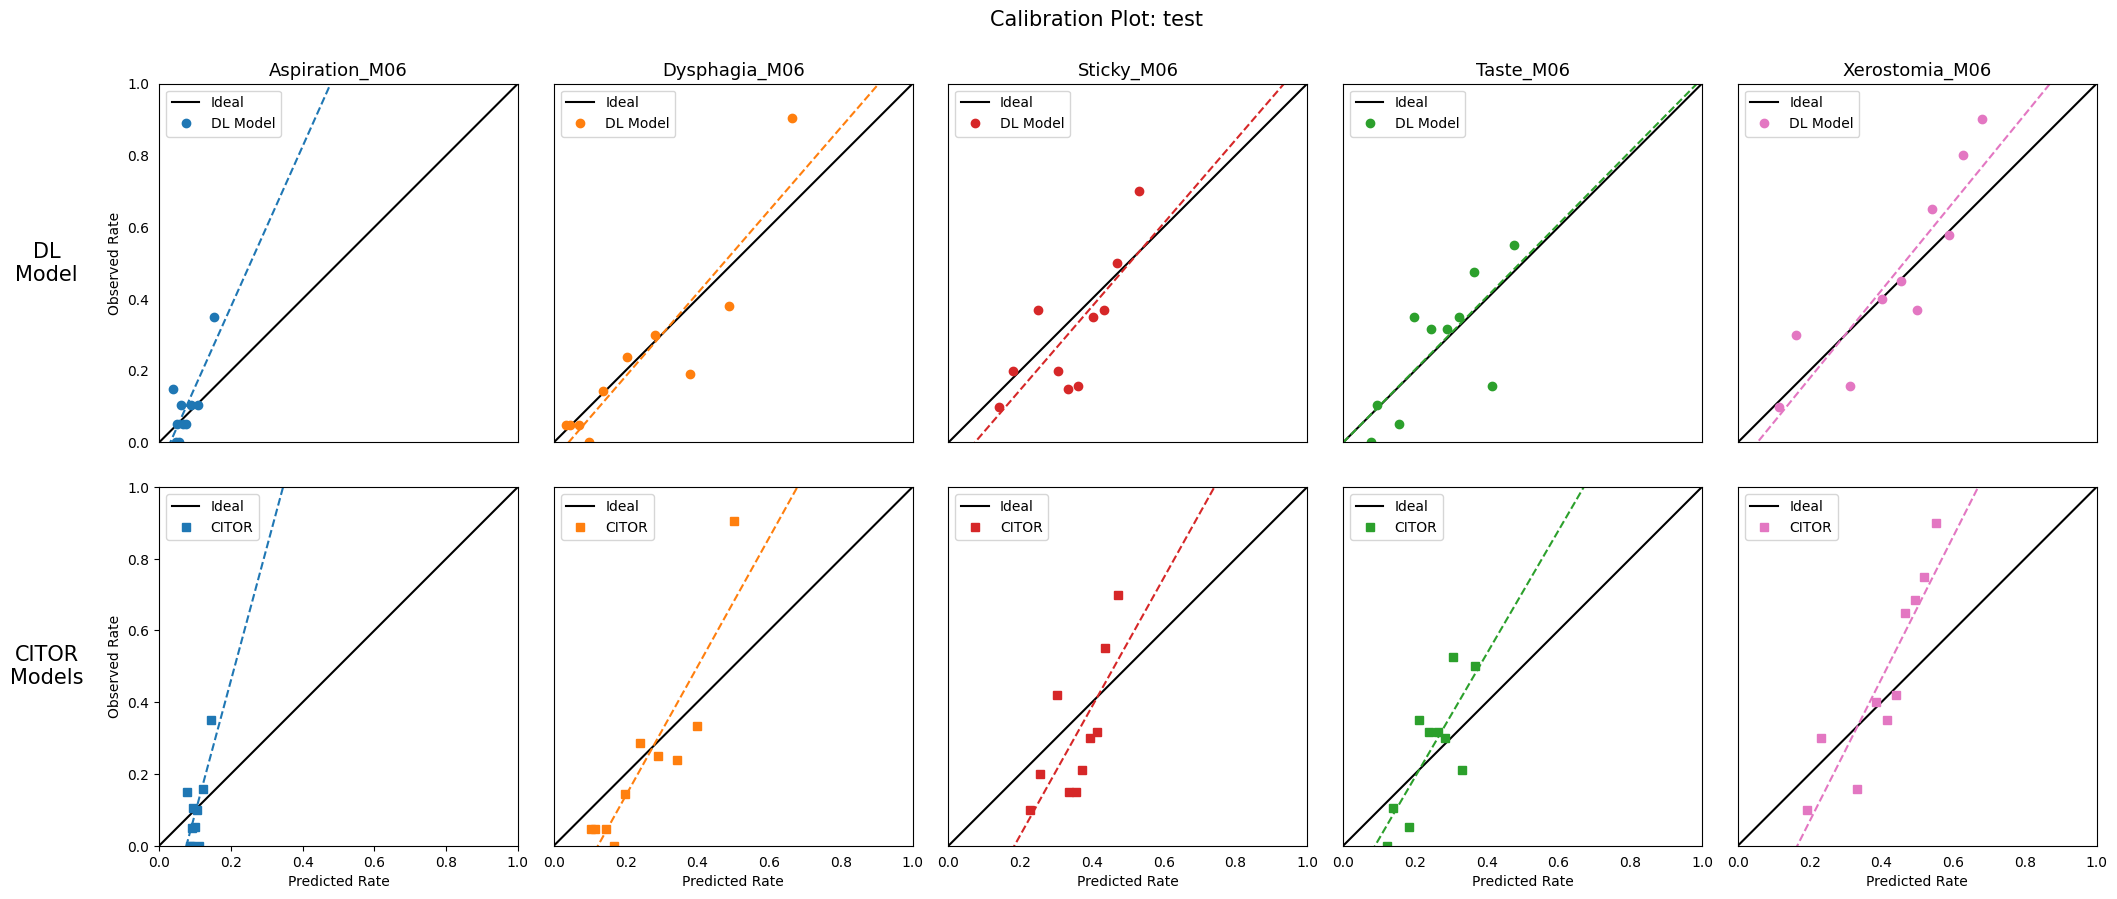

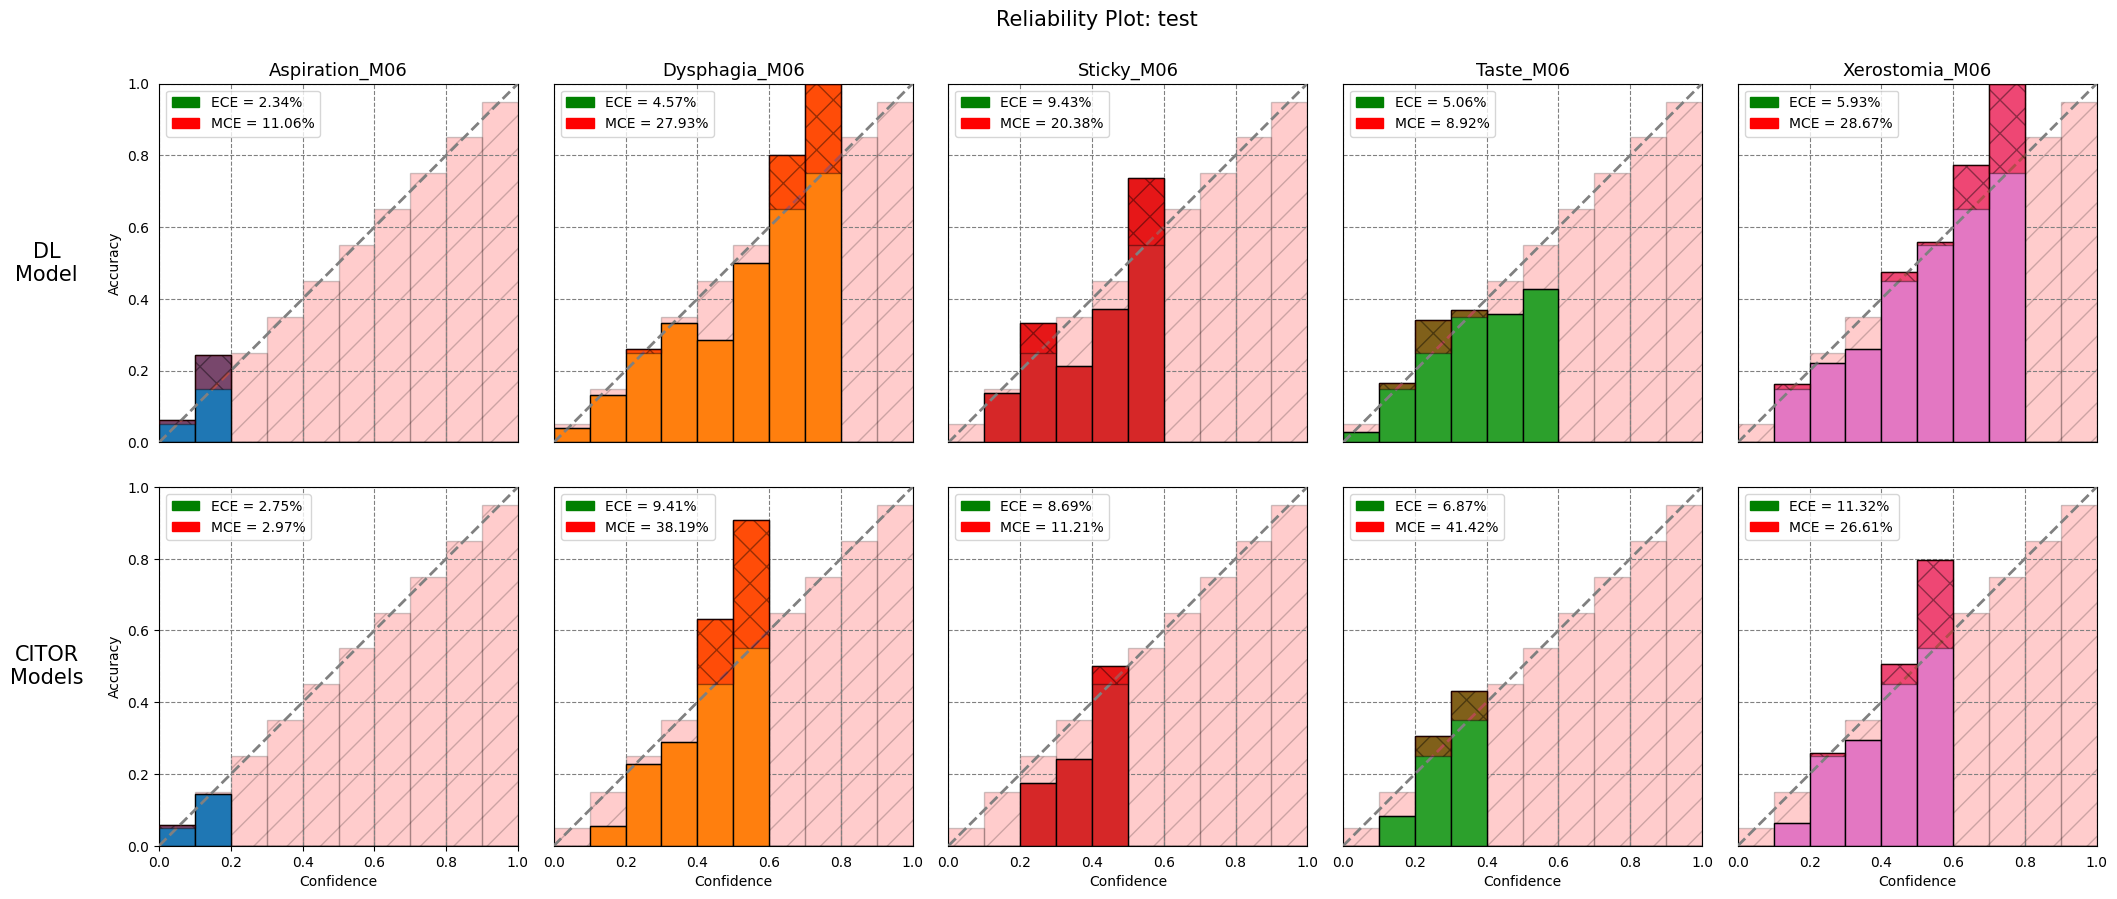

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.optimize import minimize
from scipy.special import expit, logit

class BetaCalibration(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass
    def fit(self, X, y):
        self.X = X
        self.y = y
        initial_params = [0.5, 0.5]
        res = minimize(self._neg_log_likelihood, initial_params, method='L-BFGS-B')
        #print(res)
        self.alpha_, self.beta_ = res.x
        #print(res.x)
    def _neg_log_likelihood(self, params):
        alpha, beta = params
        #print(self.X)
        probs = expit(alpha * self.X + beta)
        #print(probs)
        return -np.sum(self.y * np.log(probs) + (1 - self.y) * np.log(1 - probs))
    def predict_proba(self, X):
        return expit(self.alpha_ * X + self.beta_)
    

class BetaCalibration(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass
    def fit(self, X, y):
        self.X = X
        self.y = y
        initial_params = torch.tensor([0.5, 0.5])
        res = minimize(self._neg_log_likelihood, initial_params, method='L-BFGS-B')
        #print(res)
        self.alpha_, self.beta_ = res.x
        #print(res.x)
    def _neg_log_likelihood(self, params):
        alpha, beta = params
        #print(self.X)
        probs = torch.sigmoid(alpha * self.X + beta)
        #print(probs)
        return -torch.sum(self.y * torch.log(probs) + (1 - self.y) * torch.log(1 - probs))
    def predict_proba(self, X):
        return torch.sigmoid(self.alpha_ * X + self.beta_)

beta_model = BetaCalibration()

ens_preds_dict = {endpoint: None for endpoint in endpoints}
scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
true_labels_dict = {endpoint: None for endpoint in endpoints}

for folder in folders:
    print(folder)
    df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
    df_preds = pd.read_csv(df_preds_dir, delimiter=';')
    df_val = df_preds[df_preds['Mode'] == 'val']
    df_test = df_preds[df_preds['Mode'] == 'test']

    for endpoint in endpoints:
        # first find the scaling by using the validation set
        val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

        
        beta_model.fit(val_logits, val_labels)

        test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)

        test_logreg_preds = beta_model.predict_proba(test_logits)
        #test_logreg_preds = torch.tensor(test_logreg_preds)
        #logreg_preds = torch.sigmoid(torch.tensor(logreg_logits))

        if ens_preds_dict[endpoint] is None:
            ens_preds_dict[endpoint] = test_preds/5
            scaled_ens_preds_dict[endpoint] = test_logreg_preds/5
            true_labels_dict[endpoint] = test_labels
        else:
            ens_preds_dict[endpoint] += test_preds/5
            scaled_ens_preds_dict[endpoint] += test_logreg_preds/5
        
        

        #fig3 = plot_reliability(preds, xero_labels, 'Xerostomia_M06', n_bins=10)
        #fig3 = plot_reliability(logreg_preds, xero_labels, 'Platt Scaled Xerostomia_M06', n_bins=10)

        
       
        #given_preds_logits = torch.log(given_preds / (1 - given_preds))

        #temperature, temp_scaled_logits = set_temperature(given_preds_logits, given_labels, print_info=False)

from utils.calibration_plots import make_calibration_plots_2
import config
fig = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='calibration')
plt.show()
fig2 = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='reliability')
plt.show()

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.optimize import minimize
from scipy.special import expit, logit

class TemperatureScaling(nn.Module):
    def __init__(self):
        super(TemperatureScaling, self).__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, logits):
        return logits / self.temperature

temperature_model = TemperatureScaling()
optimizer = optim.LBFGS(temperature_model.parameters(), lr=0.01, max_iter=50)

def loss_fn():
    optimizer.zero_grad()
    scaled_logits = temperature_model(xero_preds_logits)
    loss = F.binary_cross_entropy_with_logits(scaled_logits, xero_labels)
    loss.backward()
    return loss

optimizer.step(loss_fn)



RuntimeError: result type Double can't be cast to the desired output type Long

20240622_180411_1_101_61_TransRP_ResNet18_m2_params_121328961_auc_tr_0.786_val_0.737_test_0.715
20240622_180411_2_101_54_TransRP_ResNet18_m2_params_121328961_auc_tr_0.776_val_0.744_test_0.732
20240622_180411_3_101_26_TransRP_ResNet18_m2_params_121328961_auc_tr_0.743_val_0.704_test_0.714
20240622_180411_4_101_17_TransRP_ResNet18_m2_params_121328961_auc_tr_0.711_val_0.695_test_0.699
20240622_180411_5_101_37_TransRP_ResNet18_m2_params_121328961_auc_tr_0.751_val_0.727_test_0.722_avg_tr_0.753_val_0.721_test_0.716_ens_0.732


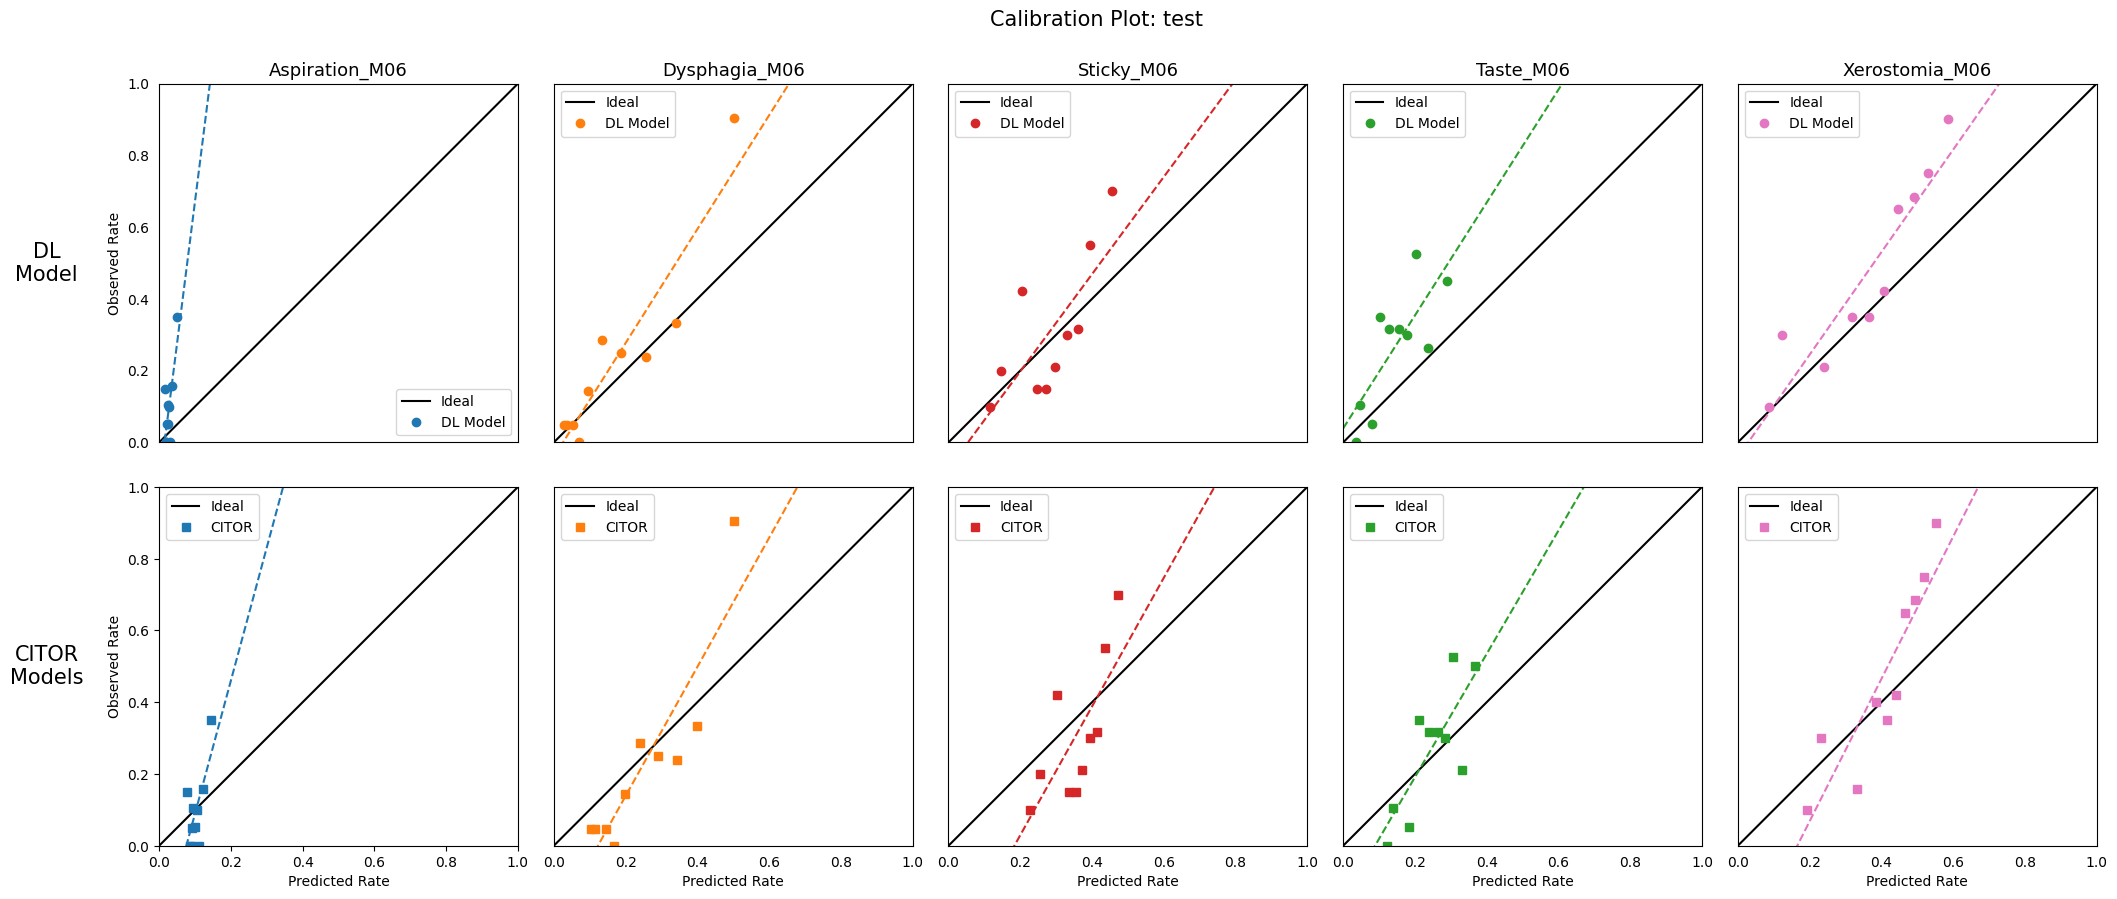

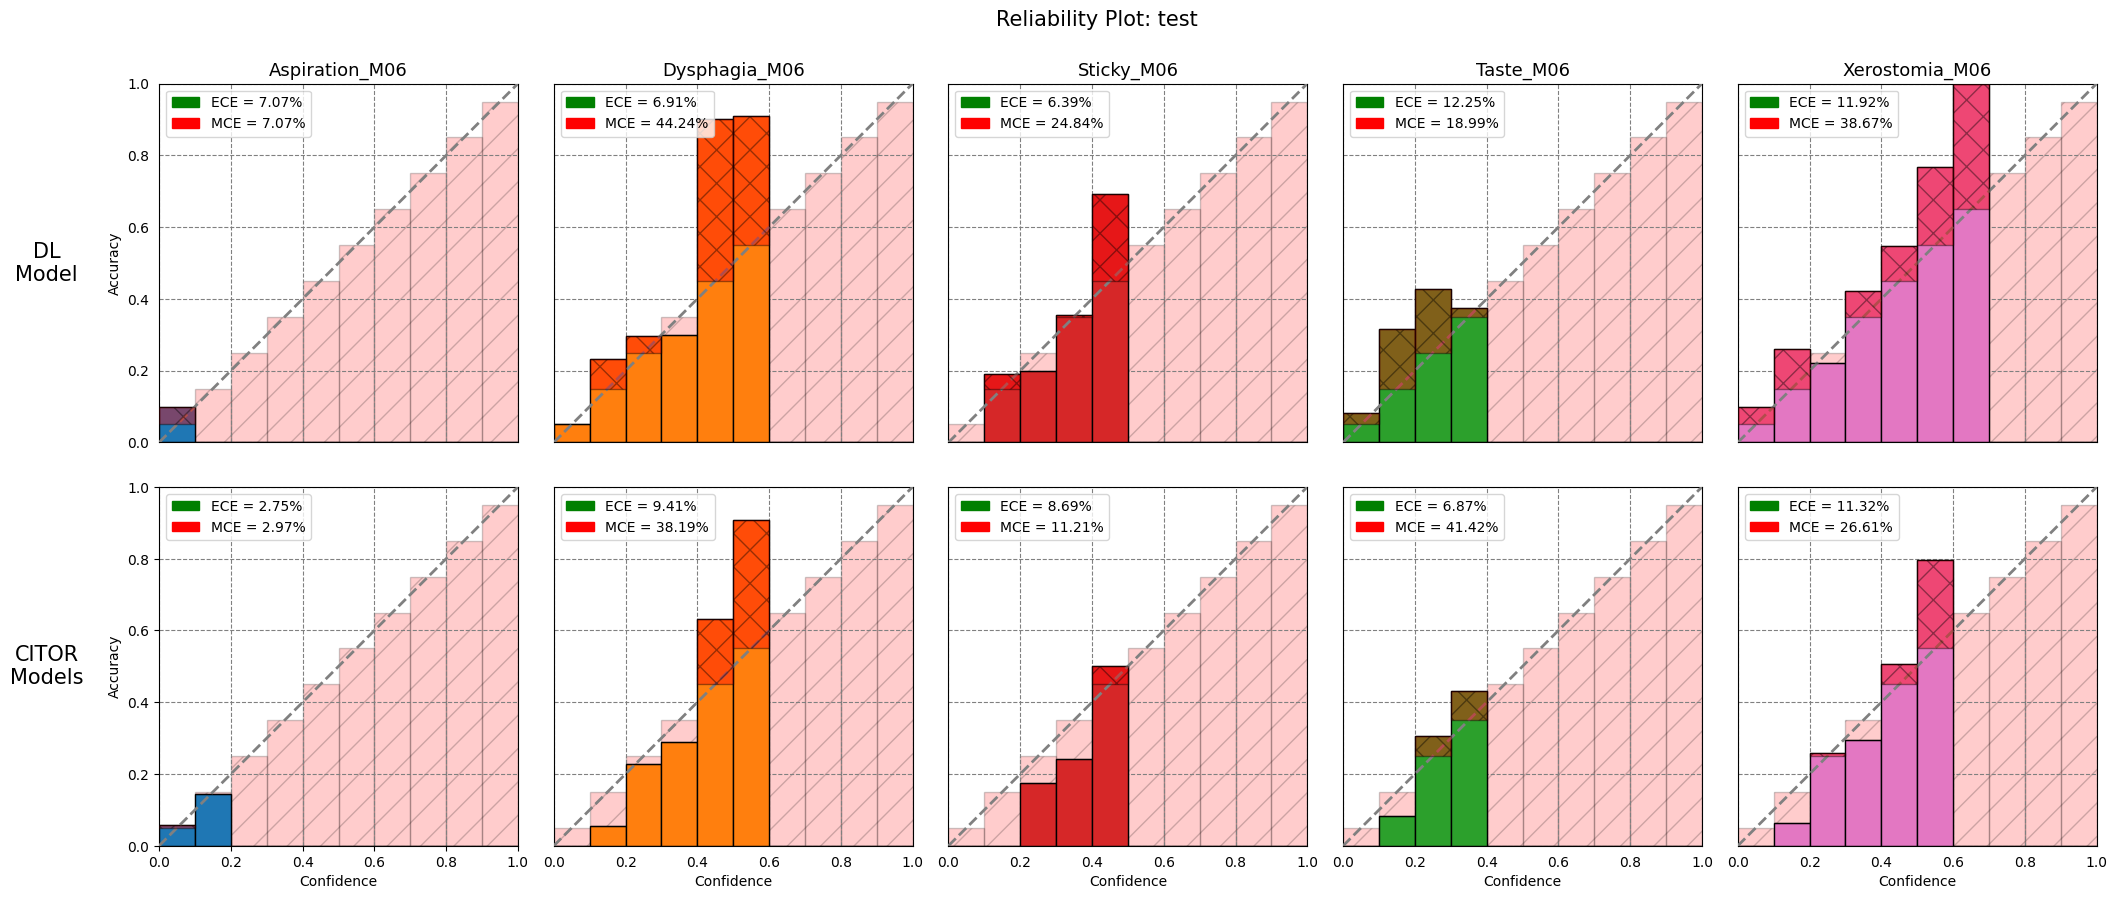

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.optimize import minimize
from scipy.special import expit, logit



ens_preds_dict = {endpoint: None for endpoint in endpoints}
scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
true_labels_dict = {endpoint: None for endpoint in endpoints}

for folder in folders:
    print(folder)
    df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
    df_preds = pd.read_csv(df_preds_dir, delimiter=';')
    df_val = df_preds[df_preds['Mode'] == 'val']
    df_test = df_preds[df_preds['Mode'] == 'test']

    for endpoint in endpoints:
        # first find the scaling by using the validation set
        val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

        temperature, temp_scaled_logits = set_temperature(val_logits, val_labels)
        


        #beta_model.fit(val_logits.numpy(), val_labels.numpy())

        test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)
        scaled_logits = temperature_scale(test_logits, temperature)
        test_logreg_preds = torch.sigmoid(scaled_logits)
        

        if ens_preds_dict[endpoint] is None:
            ens_preds_dict[endpoint] = test_preds/5
            scaled_ens_preds_dict[endpoint] = test_logreg_preds/5
            true_labels_dict[endpoint] = test_labels
        else:
            ens_preds_dict[endpoint] += test_preds/5
            scaled_ens_preds_dict[endpoint] += test_logreg_preds/5
        
        

        #fig3 = plot_reliability(preds, xero_labels, 'Xerostomia_M06', n_bins=10)
        #fig3 = plot_reliability(logreg_preds, xero_labels, 'Platt Scaled Xerostomia_M06', n_bins=10)

        
       
        #given_preds_logits = torch.log(given_preds / (1 - given_preds))

        #temperature, temp_scaled_logits = set_temperature(given_preds_logits, given_labels, print_info=False)

from utils.calibration_plots import make_calibration_plots_2
import config
fig = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='calibration')
plt.show()
fig2 = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='reliability')
plt.show()

20240622_180411_1_101_61_TransRP_ResNet18_m2_params_121328961_auc_tr_0.786_val_0.737_test_0.715
20240622_180411_2_101_54_TransRP_ResNet18_m2_params_121328961_auc_tr_0.776_val_0.744_test_0.732
20240622_180411_3_101_26_TransRP_ResNet18_m2_params_121328961_auc_tr_0.743_val_0.704_test_0.714
20240622_180411_4_101_17_TransRP_ResNet18_m2_params_121328961_auc_tr_0.711_val_0.695_test_0.699
20240622_180411_5_101_37_TransRP_ResNet18_m2_params_121328961_auc_tr_0.751_val_0.727_test_0.722_avg_tr_0.753_val_0.721_test_0.716_ens_0.732


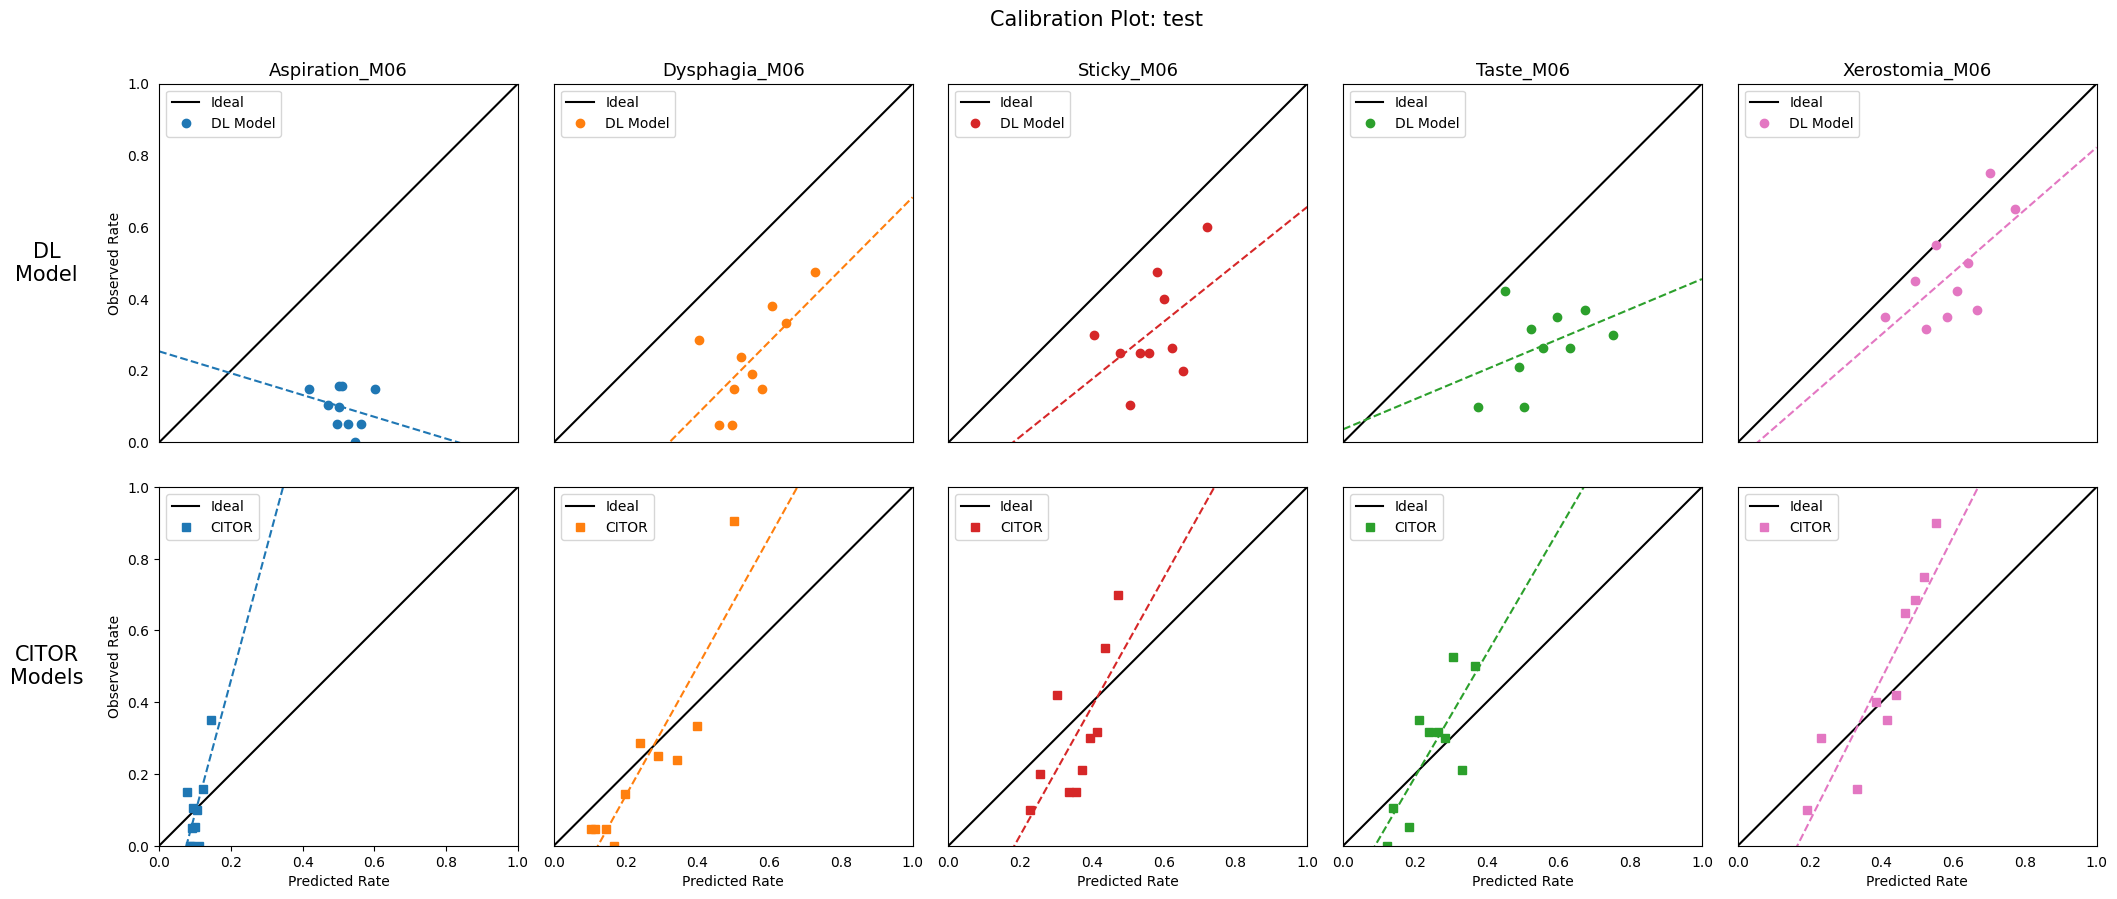

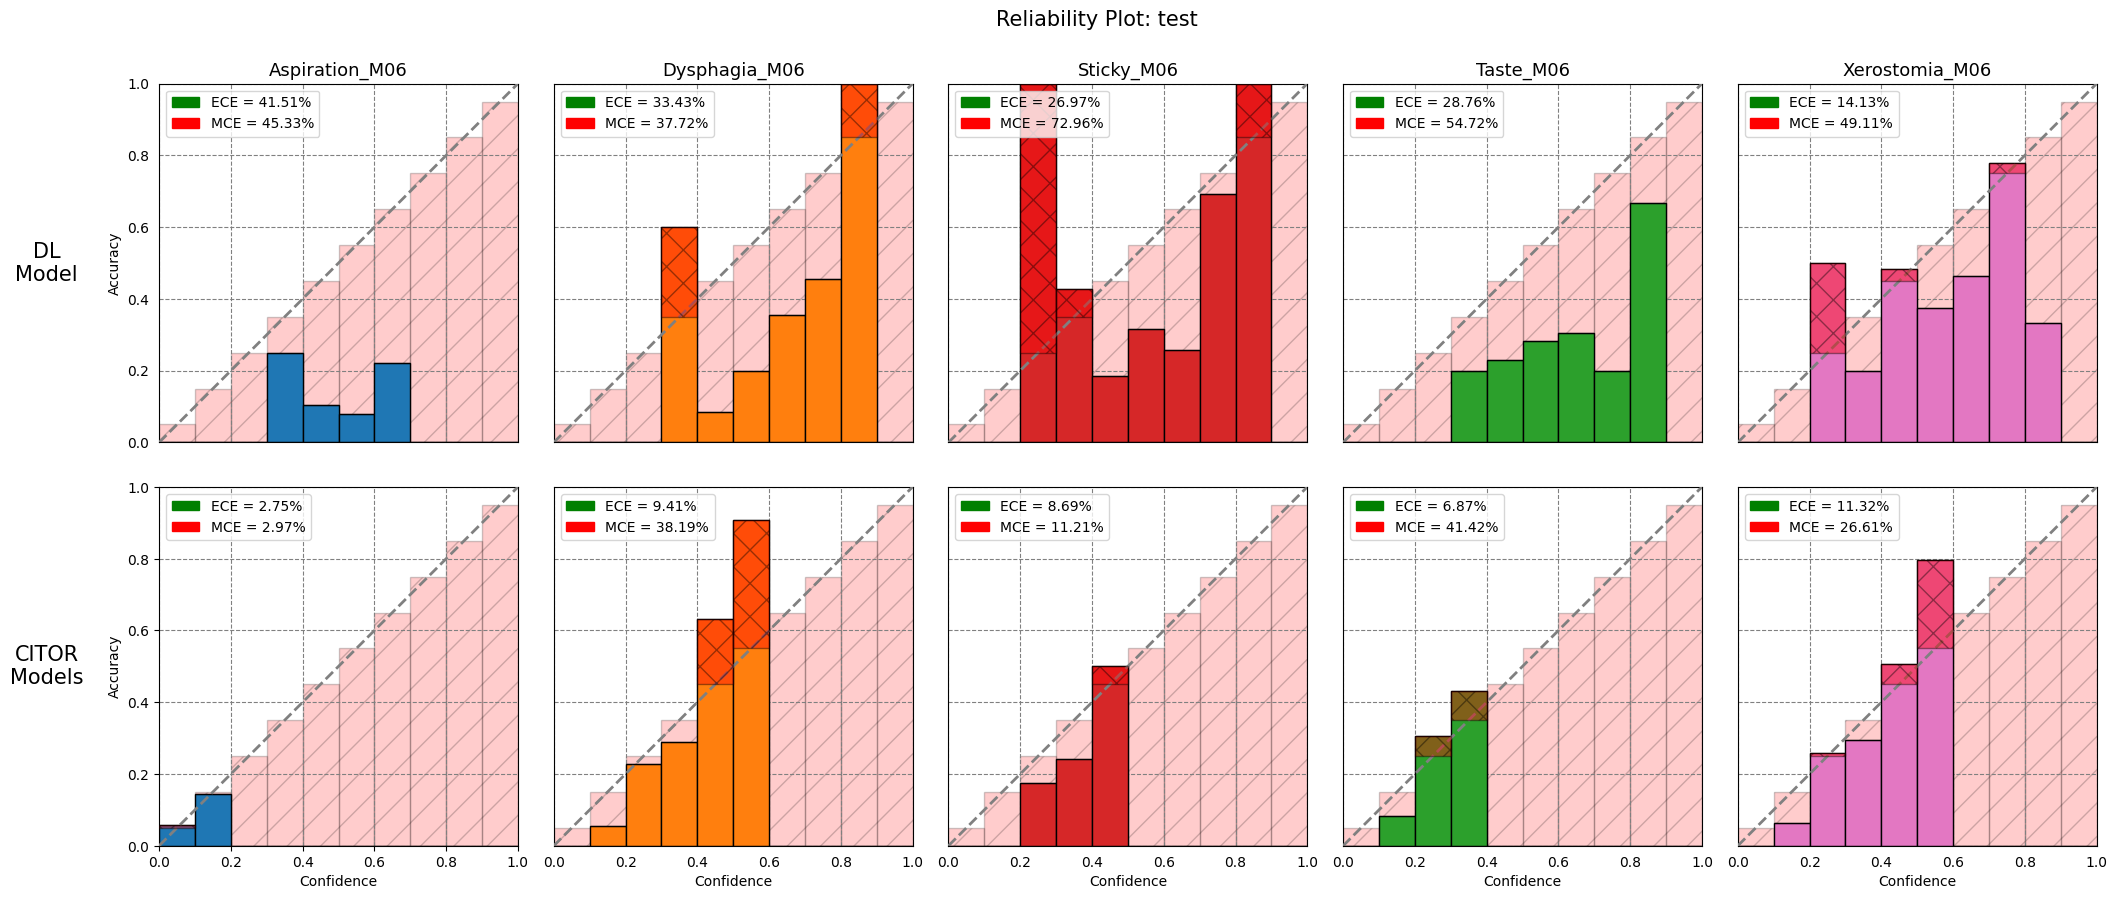

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.optimize import minimize
from scipy.special import expit, logit
from sklearn.isotonic import IsotonicRegression
from scipy.interpolate import UnivariateSpline

class SplineCalibration(BaseEstimator, RegressorMixin):
    def __init__(self, k=3, num_knots=10):
        self.k = k
        self.num_knots = num_knots

    def fit(self, X, y):
        sorted_indices = np.argsort(X)
        X = X[sorted_indices]
        y = y[sorted_indices]
        #X = X + np.arange(len(X)) * 1e-10

        #knots = np.linspace(np.min(X), np.max(X), self.num_knots)[1:-1]
        #print(knots)
        self.spline = UnivariateSpline(X, y, k=self.k, s=0)
        #print(res.x)

    def predict(self, X):
        return self.spline(X)
    

spline_model = SplineCalibration()

ens_preds_dict = {endpoint: None for endpoint in endpoints}
scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
true_labels_dict = {endpoint: None for endpoint in endpoints}

for folder in folders:
    print(folder)
    df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
    df_preds = pd.read_csv(df_preds_dir, delimiter=';')
    df_val = df_preds[df_preds['Mode'] == 'val']
    df_test = df_preds[df_preds['Mode'] == 'test']

    for endpoint in endpoints:
        # first find the scaling by using the validation set
        val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

        
        spline_model.fit(val_logits.numpy(), val_labels.numpy())

        test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)

        test_logreg_preds = spline_model.predict(test_logits.numpy())
        #test_logreg_preds = torch.tensor(test_logreg_preds)
        test_logreg_preds = torch.sigmoid(torch.tensor(test_logreg_preds))


        if ens_preds_dict[endpoint] is None:
            ens_preds_dict[endpoint] = test_preds/5
            scaled_ens_preds_dict[endpoint] = test_logreg_preds/5
            true_labels_dict[endpoint] = test_labels
        else:
            ens_preds_dict[endpoint] += test_preds/5
            scaled_ens_preds_dict[endpoint] += test_logreg_preds/5
        
        

        #fig3 = plot_reliability(preds, xero_labels, 'Xerostomia_M06', n_bins=10)
        #fig3 = plot_reliability(logreg_preds, xero_labels, 'Platt Scaled Xerostomia_M06', n_bins=10)

        
       
        #given_preds_logits = torch.log(given_preds / (1 - given_preds))

        #temperature, temp_scaled_logits = set_temperature(given_preds_logits, given_labels, print_info=False)

from utils.calibration_plots import make_calibration_plots_2
import config
fig = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='calibration')
plt.show()
fig2 = make_calibration_plots_2(config, scaled_ens_preds_dict, true_labels_dict, ens_preds_dict, true_labels_dict, set_name='test', mode='reliability')
plt.show()

In [ ]:
test_logreg_preds.max()

41.45986558849549